In [1]:
from pathlib import Path
import json
from typing import Dict, Mapping, Sequence

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display
from matplotlib.ticker import MaxNLocator, StrMethodFormatter

# Input/Output paths
DATA_PATH = Path("/home/hieule/research/reflector-position/tmp_comparison_results1/office/artifacts/elbow_plot_data.json")
OUTPUT_DIR = Path("/home/hieule/research/reflector-position/tmp_comparison_results1/office/plots/elbow-fixed")

# Method display names kept consistent with static_comparison_plotting.py
METHOD_DISPLAY_NAMES = {
    "memetic": "GA + GD",
    "pso_gd": "PSO + GD",
    "random_gd": "random + GD",
}

def display_method_name(method: str) -> str:
    return METHOD_DISPLAY_NAMES.get(method, method.replace("_", " "))

In [2]:
def load_elbow_data(path: Path) -> Dict[str, Mapping[str, object]]:
    with path.open("r", encoding="utf-8") as f:
        payload = json.load(f)
    if not isinstance(payload, dict):
        raise ValueError("Elbow plot JSON must be a dictionary at top level.")
    return payload


def _set_integer_ap_ticks(axis: plt.Axes) -> None:
    axis.xaxis.set_major_locator(MaxNLocator(integer=True))
    axis.xaxis.set_major_formatter(StrMethodFormatter("{x:.0f}"))


def plot_elbow_metric(
    metric_key: str,
    metric_payload: Mapping[str, object],
    output_dir: Path,
    with_error_band: bool = True,
    method_order: Sequence[str] | None = None,
    y_axis_range: Sequence[float] | None = None,
) -> Path:
    title = str(metric_payload.get("title", metric_key.replace("_", " ").title()))
    y_label = str(metric_payload.get("y_label", "Value"))
    per_method = metric_payload.get("per_method")
    if not isinstance(per_method, Mapping):
        raise ValueError(f"Metric '{metric_key}' does not contain a valid 'per_method' mapping.")

    methods = list(per_method.keys()) if method_order is None else [m for m in method_order if m in per_method]
    if not methods:
        raise ValueError(f"Metric '{metric_key}' has no methods to plot.")

    fig, ax = plt.subplots(figsize=(12.0, 6.0))

    for method in methods:
        method_payload = per_method[method]
        if not isinstance(method_payload, Mapping):
            continue

        x = np.asarray(method_payload.get("x", []), dtype=float)
        y = np.asarray(method_payload.get("mean", []), dtype=float)
        if x.size == 0 or y.size == 0 or x.size != y.size:
            continue

        ax.plot(x, y, linewidth=2.0, marker="o", markersize=4.0, label=display_method_name(method))

        if with_error_band:
            # lower_raw = method_payload.get("lower")
            # upper_raw = method_payload.get("upper")
            lower_raw = None
            upper_raw = None
            std_raw = method_payload.get("std")

            if isinstance(lower_raw, list) and isinstance(upper_raw, list) and len(lower_raw) == len(y) and len(upper_raw) == len(y):
                lower = np.asarray(lower_raw, dtype=float)
                upper = np.asarray(upper_raw, dtype=float)
                ax.fill_between(x, lower, upper, alpha=0.15)
            elif isinstance(std_raw, list) and len(std_raw) == len(y):
                std = np.asarray(std_raw, dtype=float)
                ax.fill_between(x, y - std, y + std, alpha=0.15)

    if y_axis_range is not None:
        if len(y_axis_range) != 2:
            raise ValueError(
                f"y_axis_range for metric '{metric_key}' must contain exactly two values: (y_min, y_max)."
            )
        y_min = float(y_axis_range[0])
        y_max = float(y_axis_range[1])
        if y_min >= y_max:
            raise ValueError(
                f"Invalid y_axis_range for metric '{metric_key}': y_min ({y_min}) must be < y_max ({y_max})."
            )
        ax.set_ylim(y_min, y_max)
    else:
        y_limits = metric_payload.get("y_limits")
        if isinstance(y_limits, Mapping):
            y_min = y_limits.get("y_min")
            y_max = y_limits.get("y_max")
            if y_min is not None and y_max is not None:
                ax.set_ylim(float(y_min), float(y_max))

    # ax.set_title(title, fontsize=22.0)
    ax.set_xlabel("AP Count", fontsize=20.0)
    ax.set_ylabel(y_label, fontsize=20.0)
    _set_integer_ap_ticks(ax)
    # increase fontsize of tick labels
    ax.tick_params(axis="both", which="major", labelsize=18.0)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best", fontsize=20.0)

    output_dir.mkdir(parents=True, exist_ok=True)
    out_path = output_dir / f"elbow_{metric_key}.png"
    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    plt.close(fig)
    return out_path


def get_method_series(
    metric_payload: Mapping[str, object],
    method_key: str,
    series_key: str,
) -> list[float]:
    per_method = metric_payload.get("per_method")
    if not isinstance(per_method, Mapping):
        raise KeyError("metric_payload does not contain a valid 'per_method' mapping.")

    method_payload = per_method.get(method_key)
    if not isinstance(method_payload, Mapping):
        raise KeyError(f"Method '{method_key}' is missing from 'per_method'.")

    series = method_payload.get(series_key)
    if not isinstance(series, list):
        raise KeyError(f"Series '{series_key}' is missing for method '{method_key}'.")

    return [float(v) for v in series]


def set_method_series(
    metric_payload: Mapping[str, object],
    method_key: str,
    series_key: str,
    new_values: Sequence[float],
) -> None:
    per_method = metric_payload.get("per_method")
    if not isinstance(per_method, dict):
        raise KeyError("metric_payload does not contain a mutable 'per_method' mapping.")

    method_payload = per_method.get(method_key)
    if not isinstance(method_payload, dict):
        raise KeyError(f"Method '{method_key}' is missing from 'per_method'.")

    x_vals = method_payload.get("x")
    if isinstance(x_vals, list) and len(x_vals) != len(new_values):
        raise ValueError(
            f"Length mismatch for '{method_key}.{series_key}': expected {len(x_vals)}, got {len(new_values)}."
        )

    method_payload[series_key] = [float(v) for v in new_values]


def method_table(method_payload: Mapping[str, object]) -> pd.DataFrame:
    x = list(method_payload.get("x", []))
    mean = list(method_payload.get("mean", []))
    std = list(method_payload.get("std", []))
    lower = list(method_payload.get("lower", []))
    upper = list(method_payload.get("upper", []))

    df = pd.DataFrame(
        {
            "AP Count": x,
            "Mean": mean,
            "Std": std if len(std) == len(x) else [np.nan] * len(x),
            "Lower": lower if len(lower) == len(x) else [np.nan] * len(x),
            "Upper": upper if len(upper) == len(x) else [np.nan] * len(x),
        }
    )
    return df


def display_metric_method_tables(
    metric_key: str,
    metric_payload: Mapping[str, object],
    method_order: Sequence[str] | None = None,
) -> None:
    per_method = metric_payload.get("per_method")
    if not isinstance(per_method, Mapping):
        return

    metric_title = str(metric_payload.get("title", metric_key))
    display(Markdown(f"## Tables: {metric_title} ({metric_key})"))

    methods = list(per_method.keys()) if method_order is None else [m for m in method_order if m in per_method]
    for method in methods:
        method_payload = per_method[method]
        if not isinstance(method_payload, Mapping):
            continue
        df = method_table(method_payload)
        display(Markdown(f"### Method: {display_method_name(method)} (`{method}`)"))
        display(df)


def display_saved_plots(paths: Sequence[Path]) -> None:
    for path in paths:
        display(Markdown(f"## Plot: {path.name}"))
        display(Image(filename=str(path)))

In [3]:
# Load elbow JSON into pandas DataFrames for analysis and inspect the first rows
elbow_data = load_elbow_data(DATA_PATH)

metric_order = [
    "primary_loss",
    "mean_rss_dbm",
    "min_rss_dbm",
    "p5_rss_dbm",
    "priority_mean_rss_dbm",
    "priority_min_rss_dbm",
    "priority_p5_rss_dbm",
]

method_order = ["memetic", "pso_gd", "random_gd", "kmeans", "weighted_kmeans", "random"]

rows = []
for metric_key in metric_order:
    metric_payload = elbow_data.get(metric_key)
    if not isinstance(metric_payload, Mapping):
        continue

    per_method = metric_payload.get("per_method")
    if not isinstance(per_method, Mapping):
        continue

    methods = [m for m in method_order if m in per_method]
    for method in methods:
        method_payload = per_method.get(method, {})
        if not isinstance(method_payload, Mapping):
            continue

        x_vals = list(method_payload.get("x", []))
        mean_vals = list(method_payload.get("mean", []))
        std_vals = list(method_payload.get("std", []))
        lower_vals = list(method_payload.get("lower", []))
        upper_vals = list(method_payload.get("upper", []))

        n = min(
            len(x_vals),
            len(mean_vals),
            len(std_vals) if std_vals else len(x_vals),
            len(lower_vals) if lower_vals else len(x_vals),
            len(upper_vals) if upper_vals else len(x_vals),
        )

        for i in range(n):
            rows.append(
                {
                    "metric": metric_key,
                    "method": method,
                    "method_display": display_method_name(method),
                    "ap_count": int(x_vals[i]),
                    "mean": float(mean_vals[i]),
                    "std": float(std_vals[i]) if std_vals else np.nan,
                    "lower": float(lower_vals[i]) if lower_vals else np.nan,
                    "upper": float(upper_vals[i]) if upper_vals else np.nan,
                }
            )

df_long = pd.DataFrame(rows).sort_values(["metric", "method", "ap_count"]).reset_index(drop=True)

# Optional wide format for metric-wise comparison (mean only)
df_wide_mean = df_long.pivot_table(
    index=["metric", "ap_count"],
    columns="method_display",
    values="mean",
    aggfunc="first",
).reset_index()



In [4]:
print("df_long shape:", df_long.shape)
print("df_long head:")
df_long.head(20)

df_long shape: (294, 8)
df_long head:


,metric,method,method_display,ap_count,mean,std,lower,upper
0,mean_rss_dbm,kmeans,kmeans,1,-58.339383,0.000731,-58.340114,-58.338652
1,mean_rss_dbm,kmeans,kmeans,2,-54.469524,2.859519,-57.329043,-51.610005
2,mean_rss_dbm,kmeans,kmeans,3,-50.749033,1.039438,-51.788471,-49.709595
3,mean_rss_dbm,kmeans,kmeans,4,-48.457321,0.007833,-48.465154,-48.449488
4,mean_rss_dbm,kmeans,kmeans,5,-46.931972,0.368828,-47.300799,-46.563144
5,mean_rss_dbm,kmeans,kmeans,6,-45.774374,0.466229,-46.240602,-45.308145
6,mean_rss_dbm,kmeans,kmeans,7,-44.350333,0.232436,-44.582769,-44.117897
7,mean_rss_dbm,memetic,GA + GD,1,-57.191984,0.942371,-58.134354,-56.249613
8,mean_rss_dbm,memetic,GA + GD,2,-50.365596,0.584876,-50.950472,-49.780720
9,mean_rss_dbm,memetic,GA + GD,3,-48.298392,0.504505,-49.802897,-48.793887


In [5]:
print("\ndf_wide_mean shape:", df_wide_mean.shape)
print("df_wide_mean head:")
df_wide_mean.head()


df_wide_mean shape: (49, 8)
df_wide_mean head:


method_display,metric,ap_count,GA + GD,PSO + GD,kmeans,random,random + GD,weighted kmeans
0,mean_rss_dbm,1,-57.191984,-57.282762,-58.339383,-65.109382,-60.409637,-58.346874
1,mean_rss_dbm,2,-50.365596,-49.820094,-54.469524,-57.757104,-54.687708,-52.509914
2,mean_rss_dbm,3,-48.298392,-47.084566,-50.749033,-53.529779,-50.601320,-50.187340
3,mean_rss_dbm,4,-46.413000,-46.055946,-48.457321,-51.239167,-48.616002,-48.170882
4,mean_rss_dbm,5,-44.981302,-45.028088,-46.931972,-49.434710,-46.536086,-46.996519


Saved: /home/hieule/research/reflector-position/tmp_comparison_results1/office/plots/elbow-fixed/elbow_primary_loss.png
Saved: /home/hieule/research/reflector-position/tmp_comparison_results1/office/plots/elbow-fixed/elbow_mean_rss_dbm.png
Applied y-axis range for mean_rss_dbm: (-75.0, -40.0)
Saved: /home/hieule/research/reflector-position/tmp_comparison_results1/office/plots/elbow-fixed/elbow_min_rss_dbm.png
Applied y-axis range for min_rss_dbm: (-120.0, -50.0)
Saved: /home/hieule/research/reflector-position/tmp_comparison_results1/office/plots/elbow-fixed/elbow_p5_rss_dbm.png
Applied y-axis range for p5_rss_dbm: (-95.0, -45.0)
Saved: /home/hieule/research/reflector-position/tmp_comparison_results1/office/plots/elbow-fixed/elbow_priority_mean_rss_dbm.png
Applied y-axis range for priority_mean_rss_dbm: (-75.0, -40.0)
Saved: /home/hieule/research/reflector-position/tmp_comparison_results1/office/plots/elbow-fixed/elbow_priority_min_rss_dbm.png
Applied y-axis range for priority_min_rss_d

# Generated Elbow Plots

## Plot: elbow_primary_loss.png

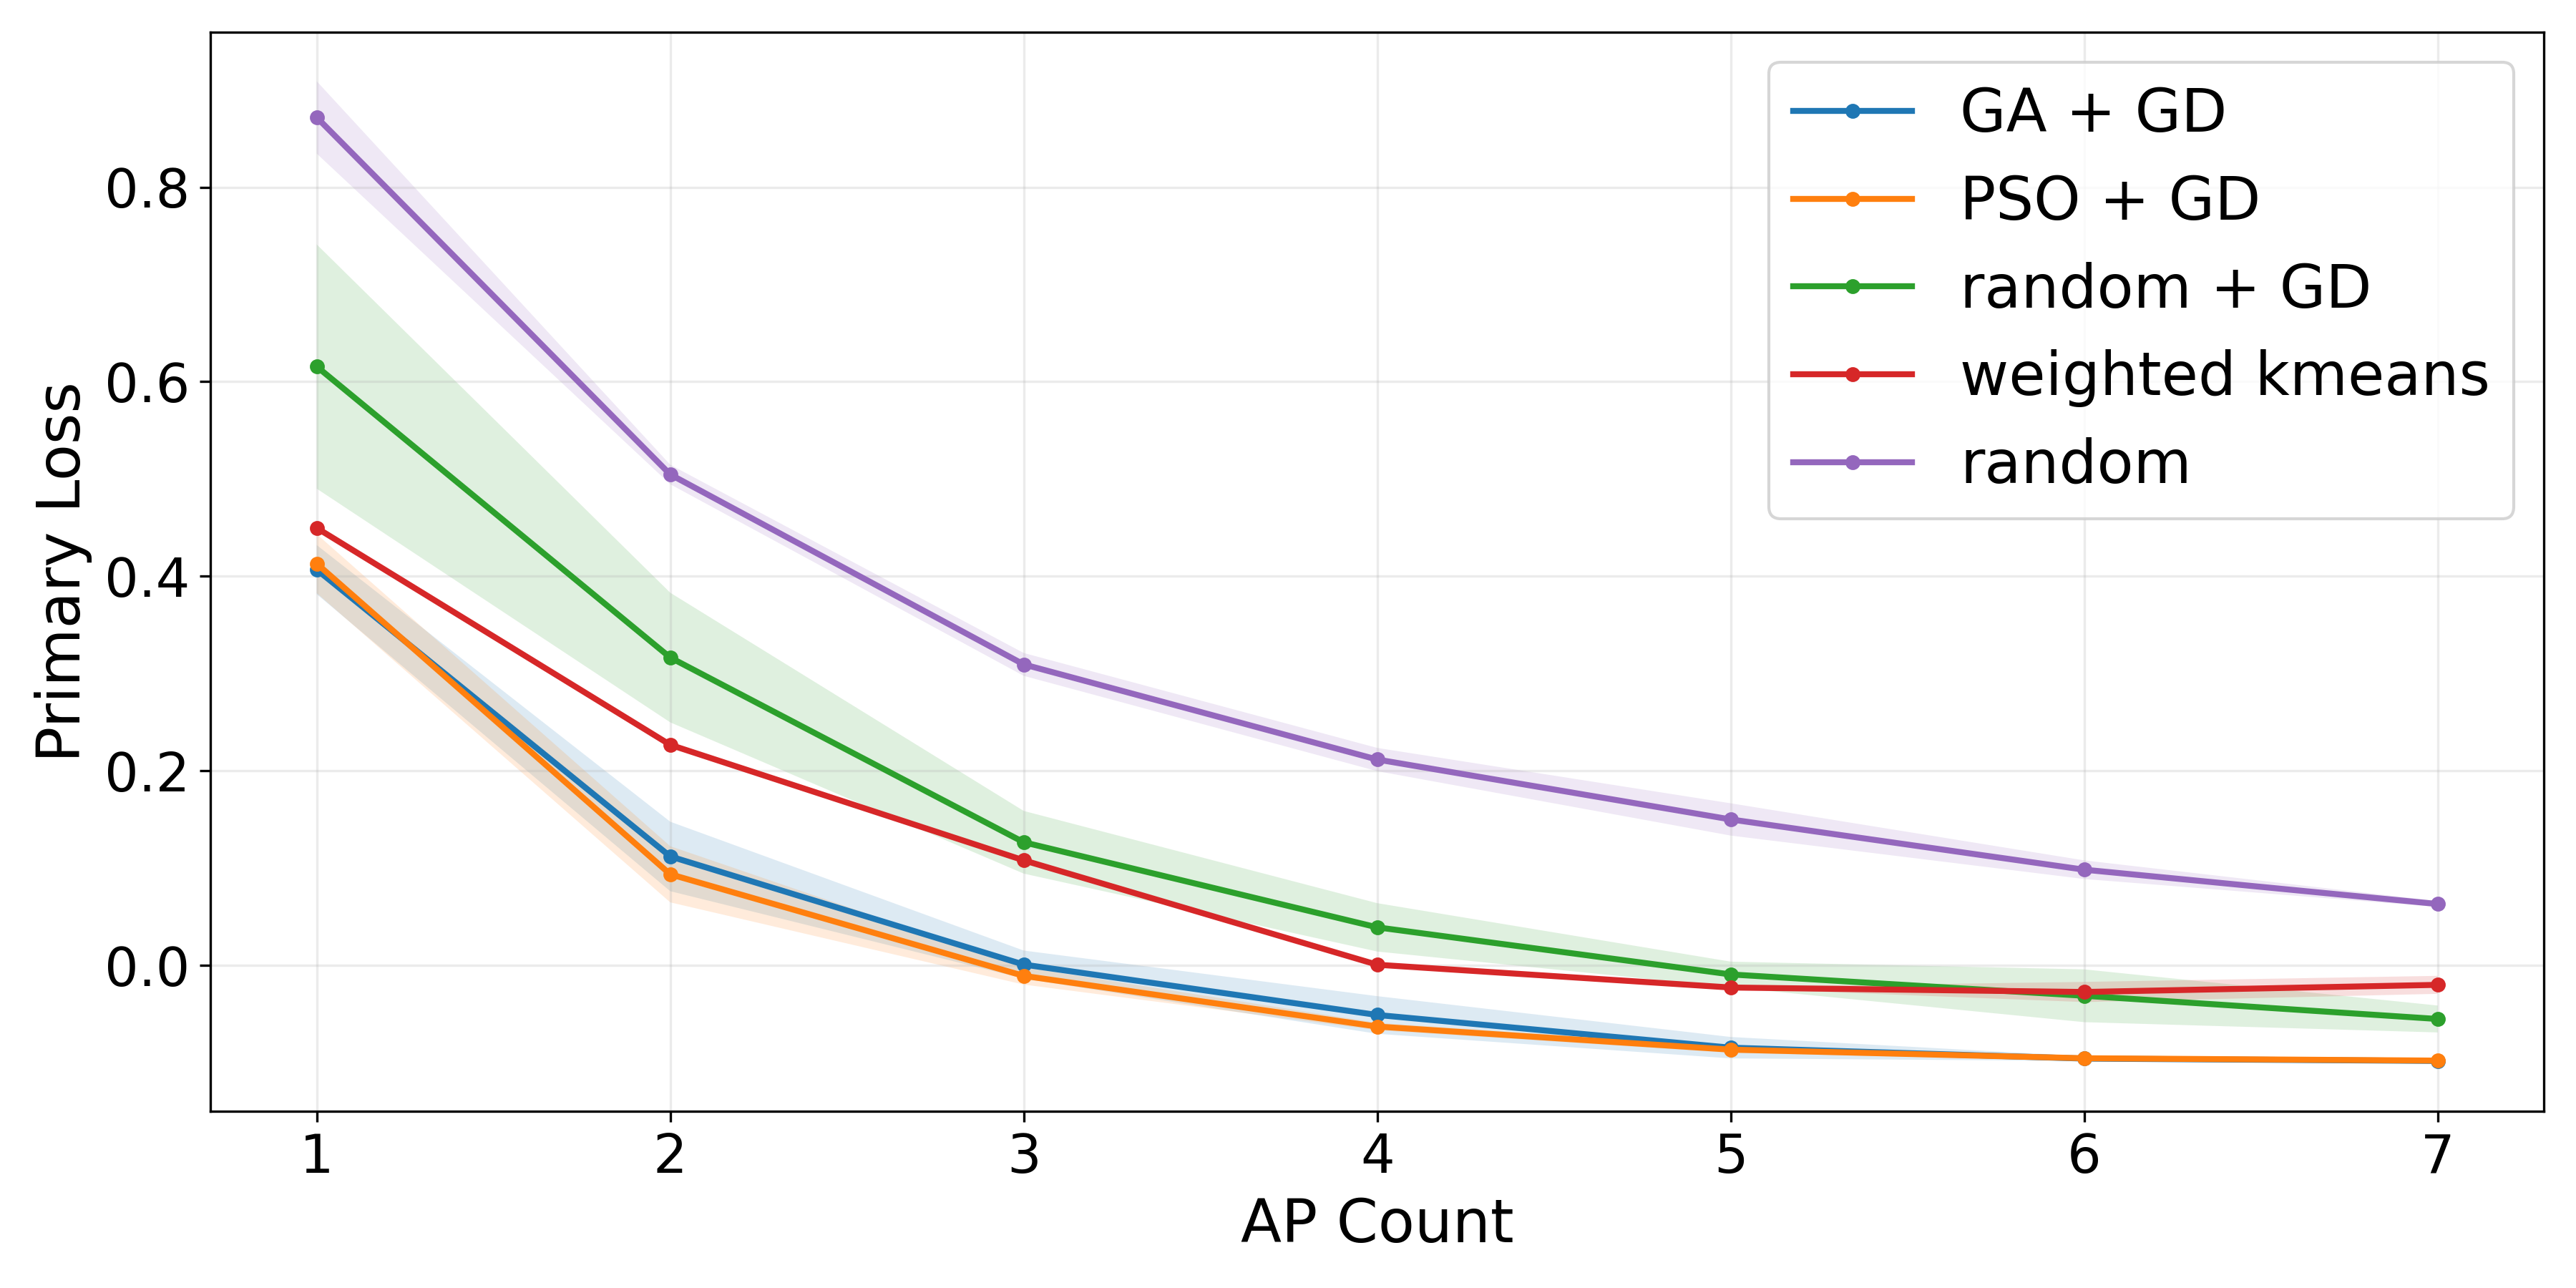

## Plot: elbow_mean_rss_dbm.png

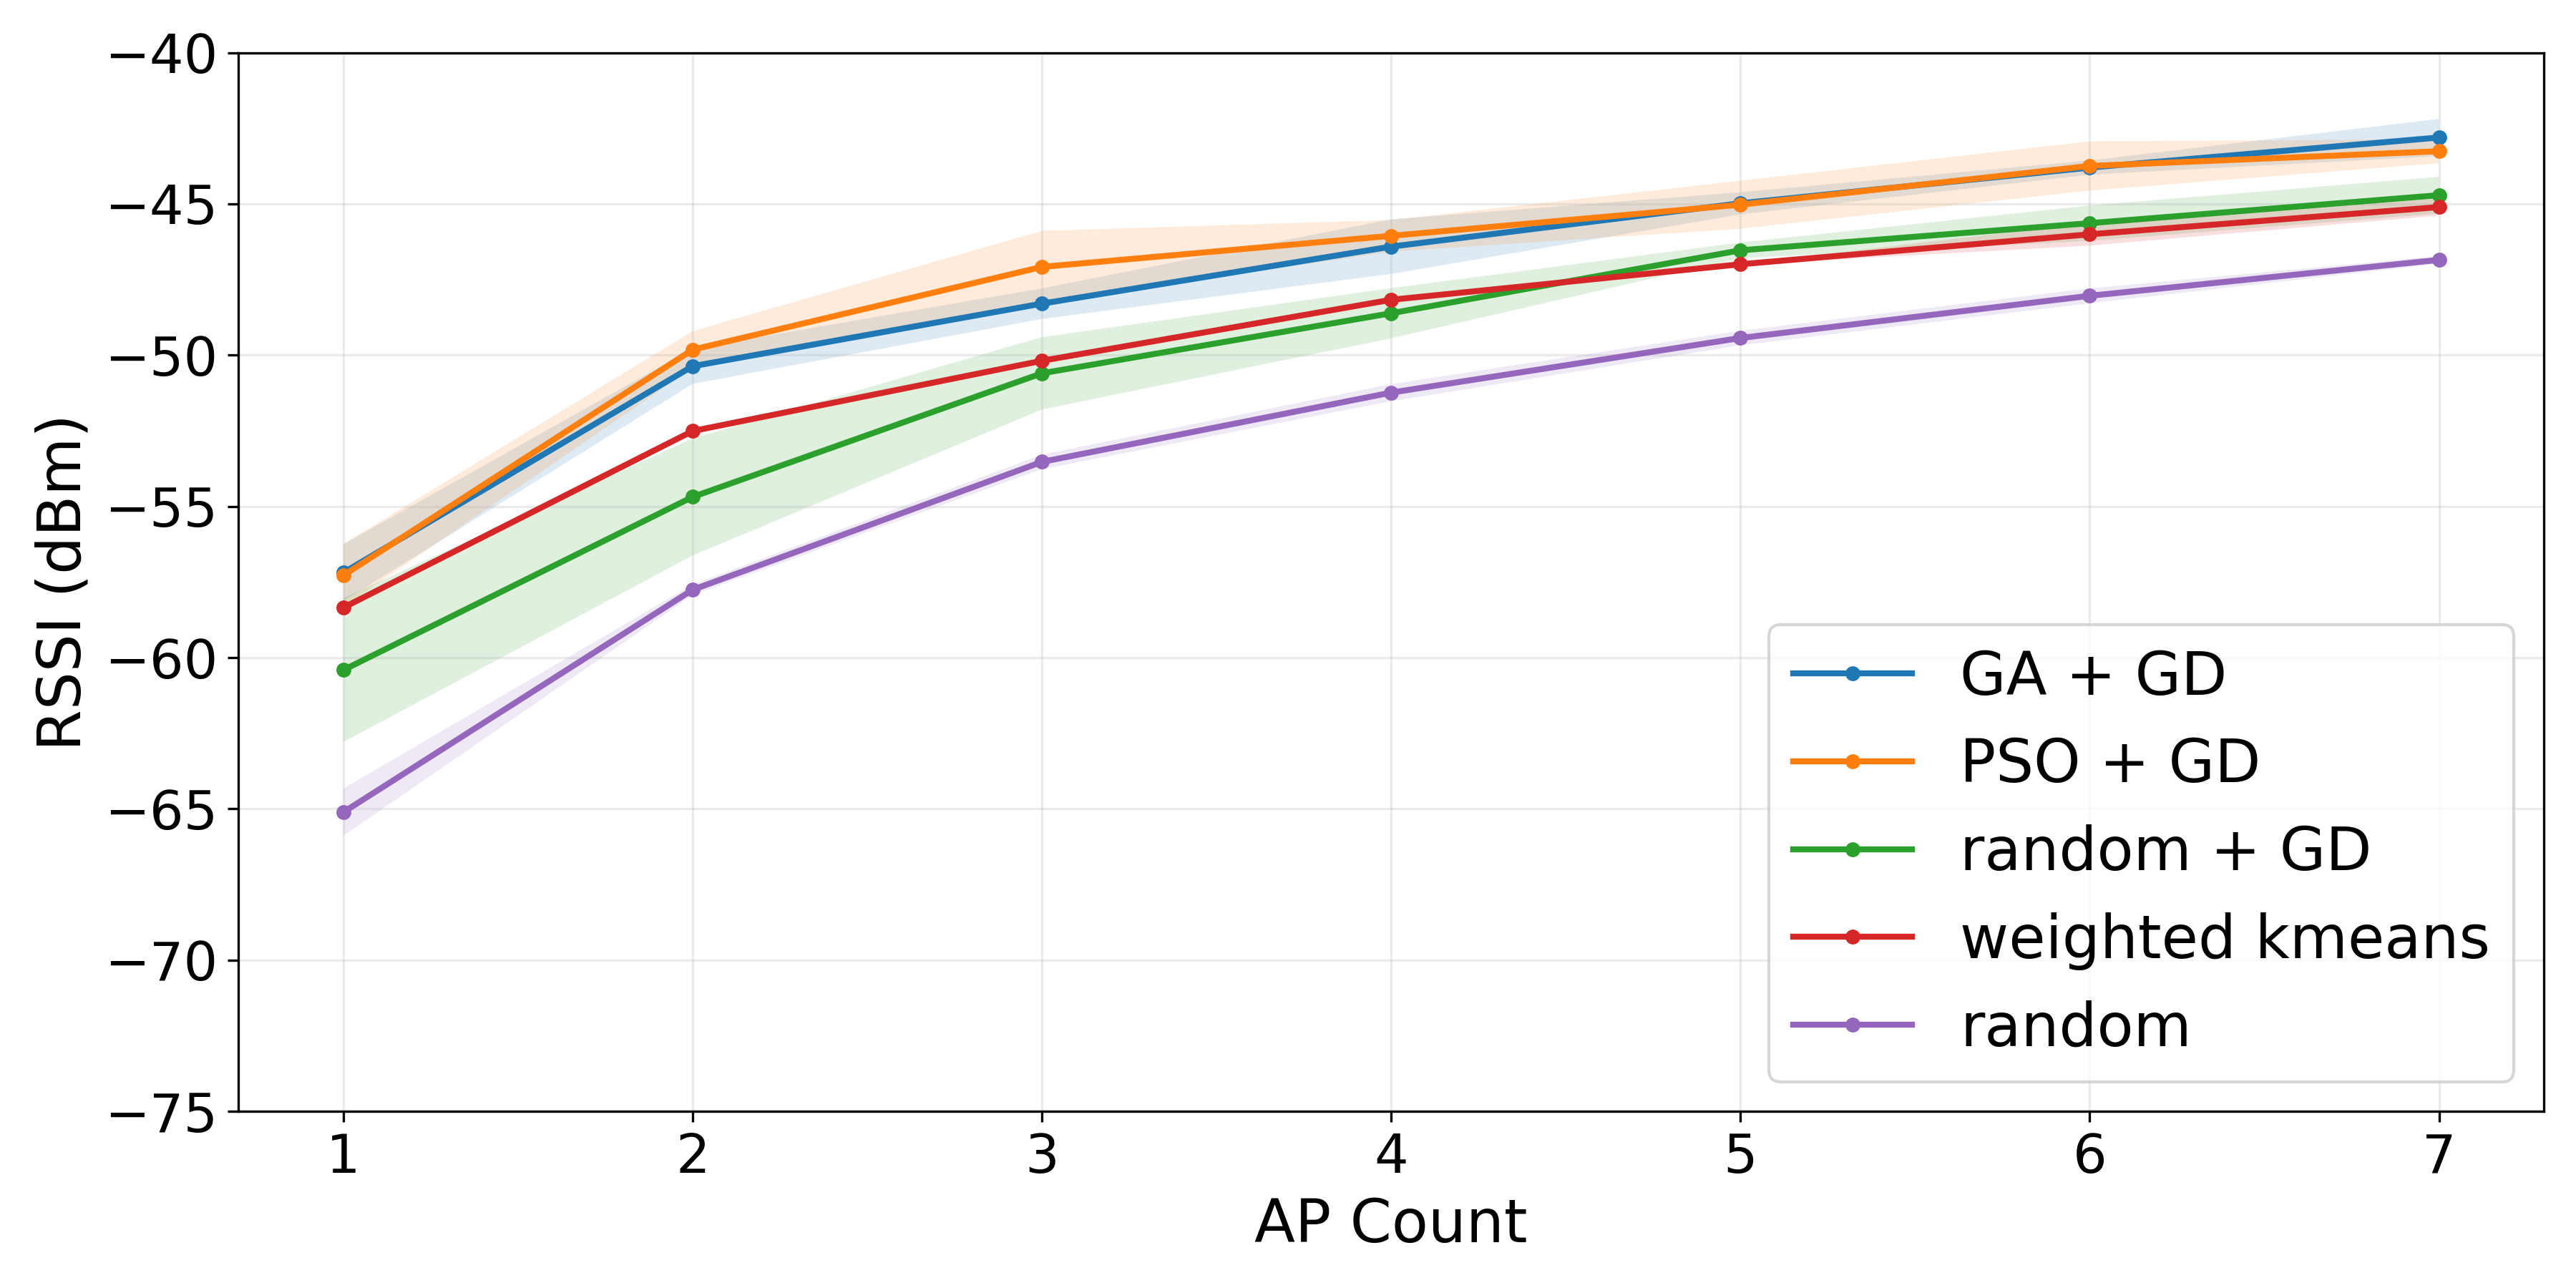

## Plot: elbow_min_rss_dbm.png

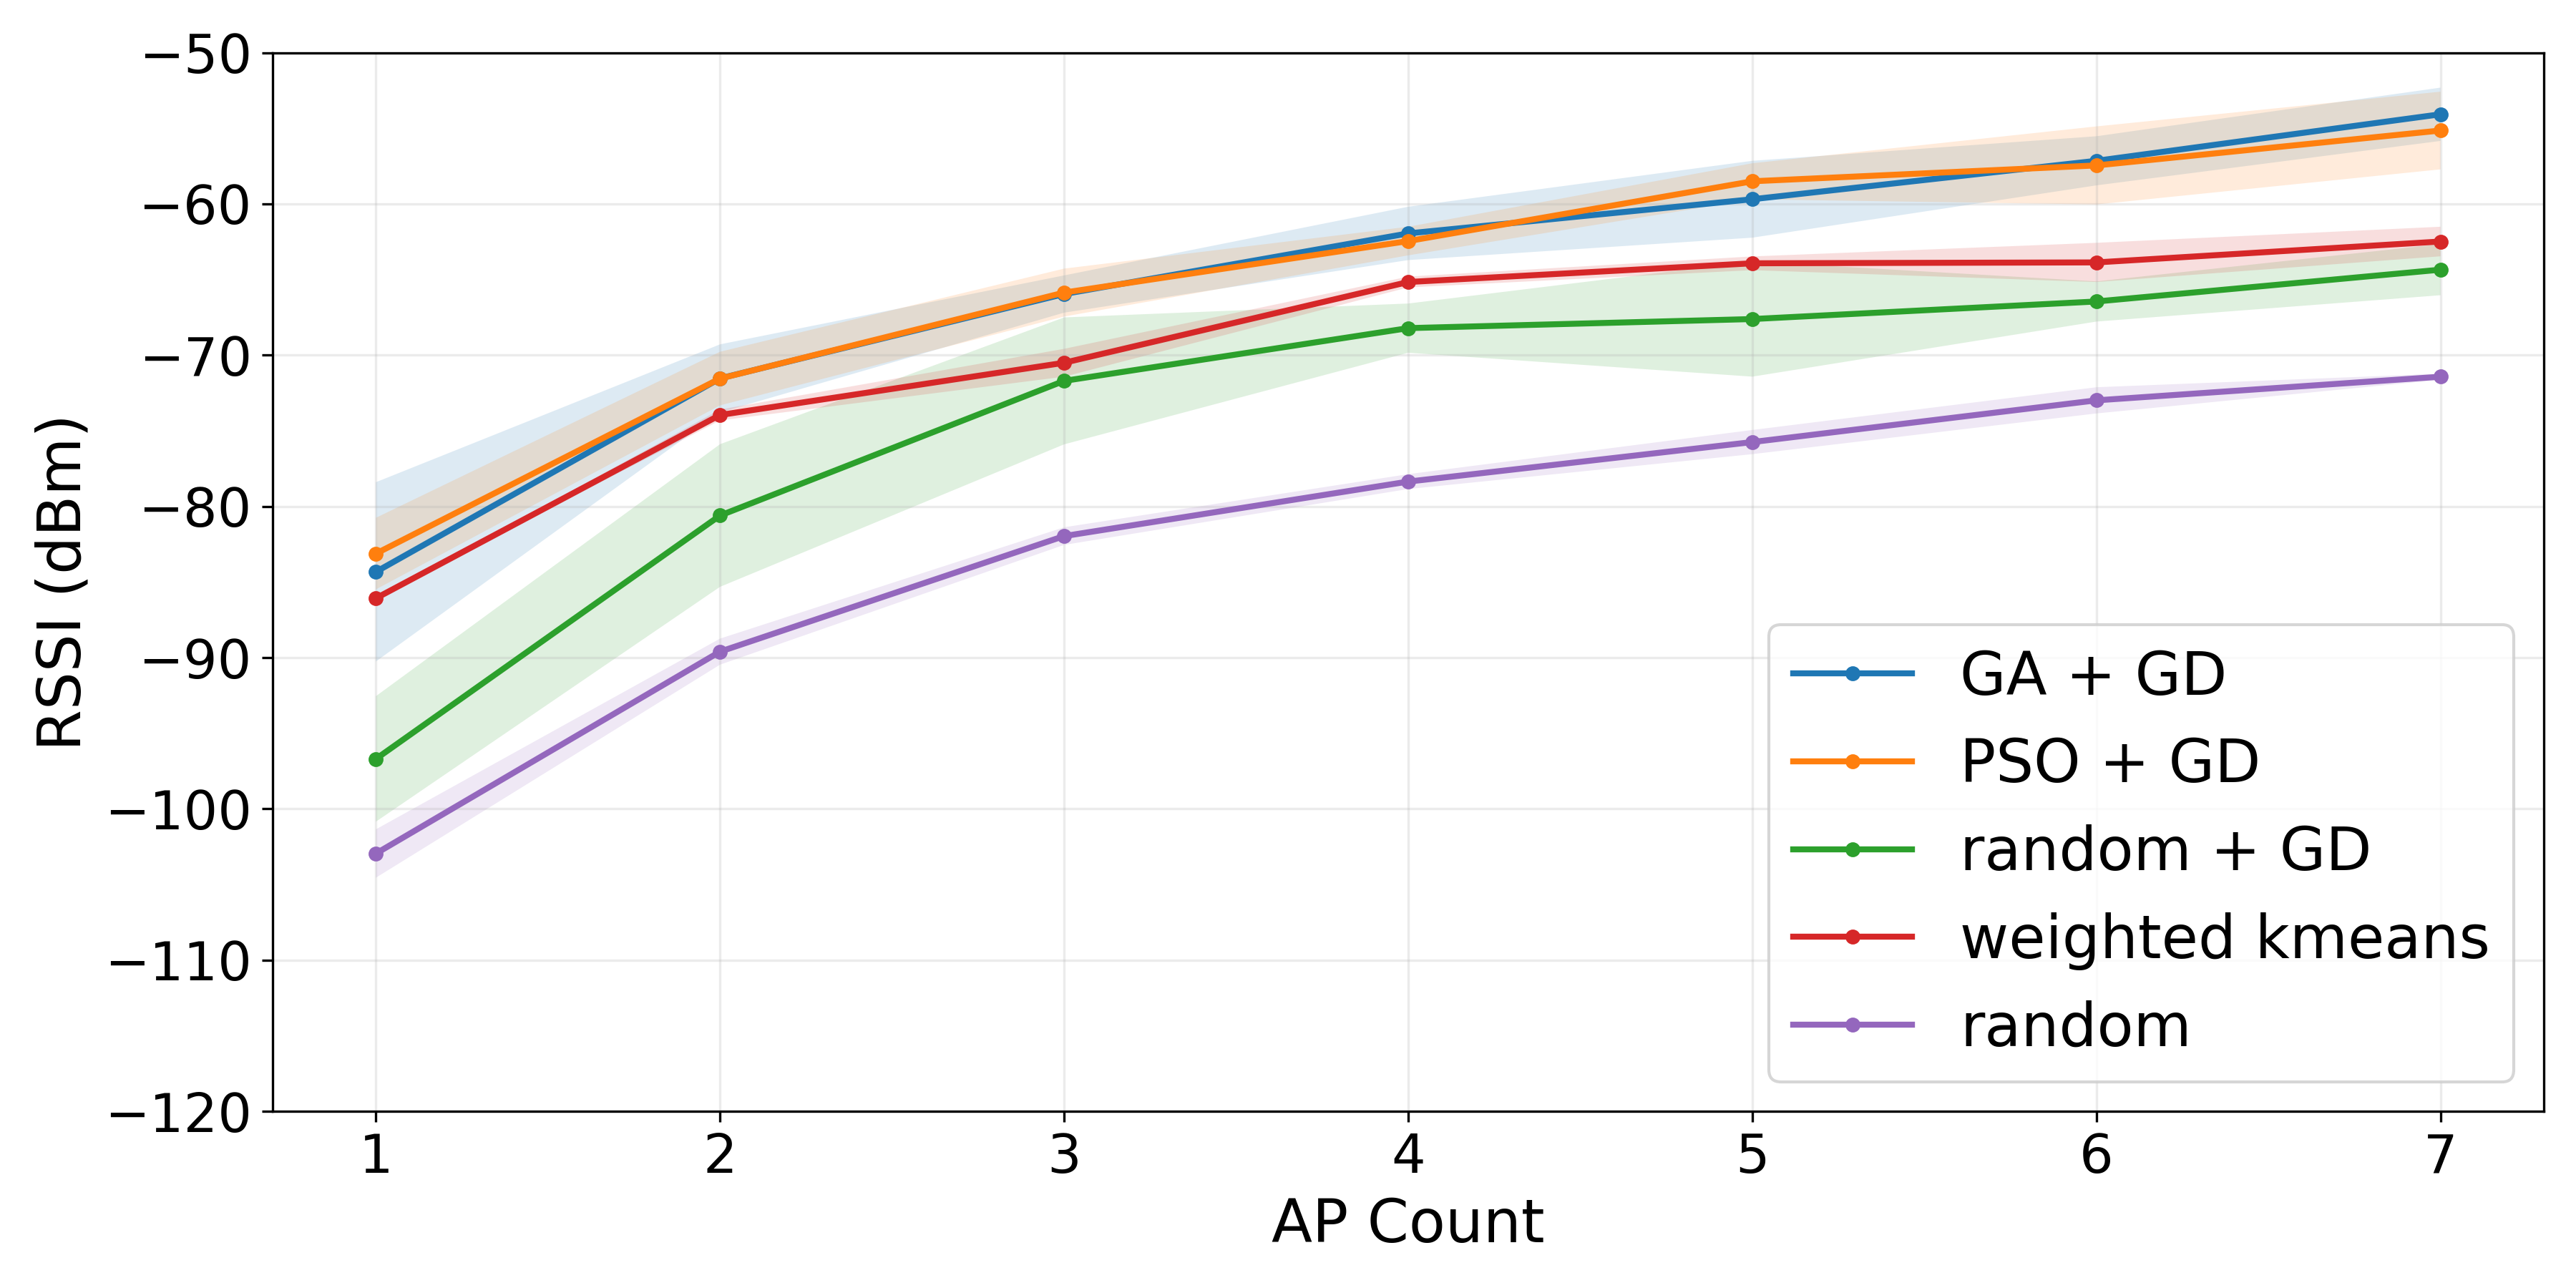

## Plot: elbow_p5_rss_dbm.png

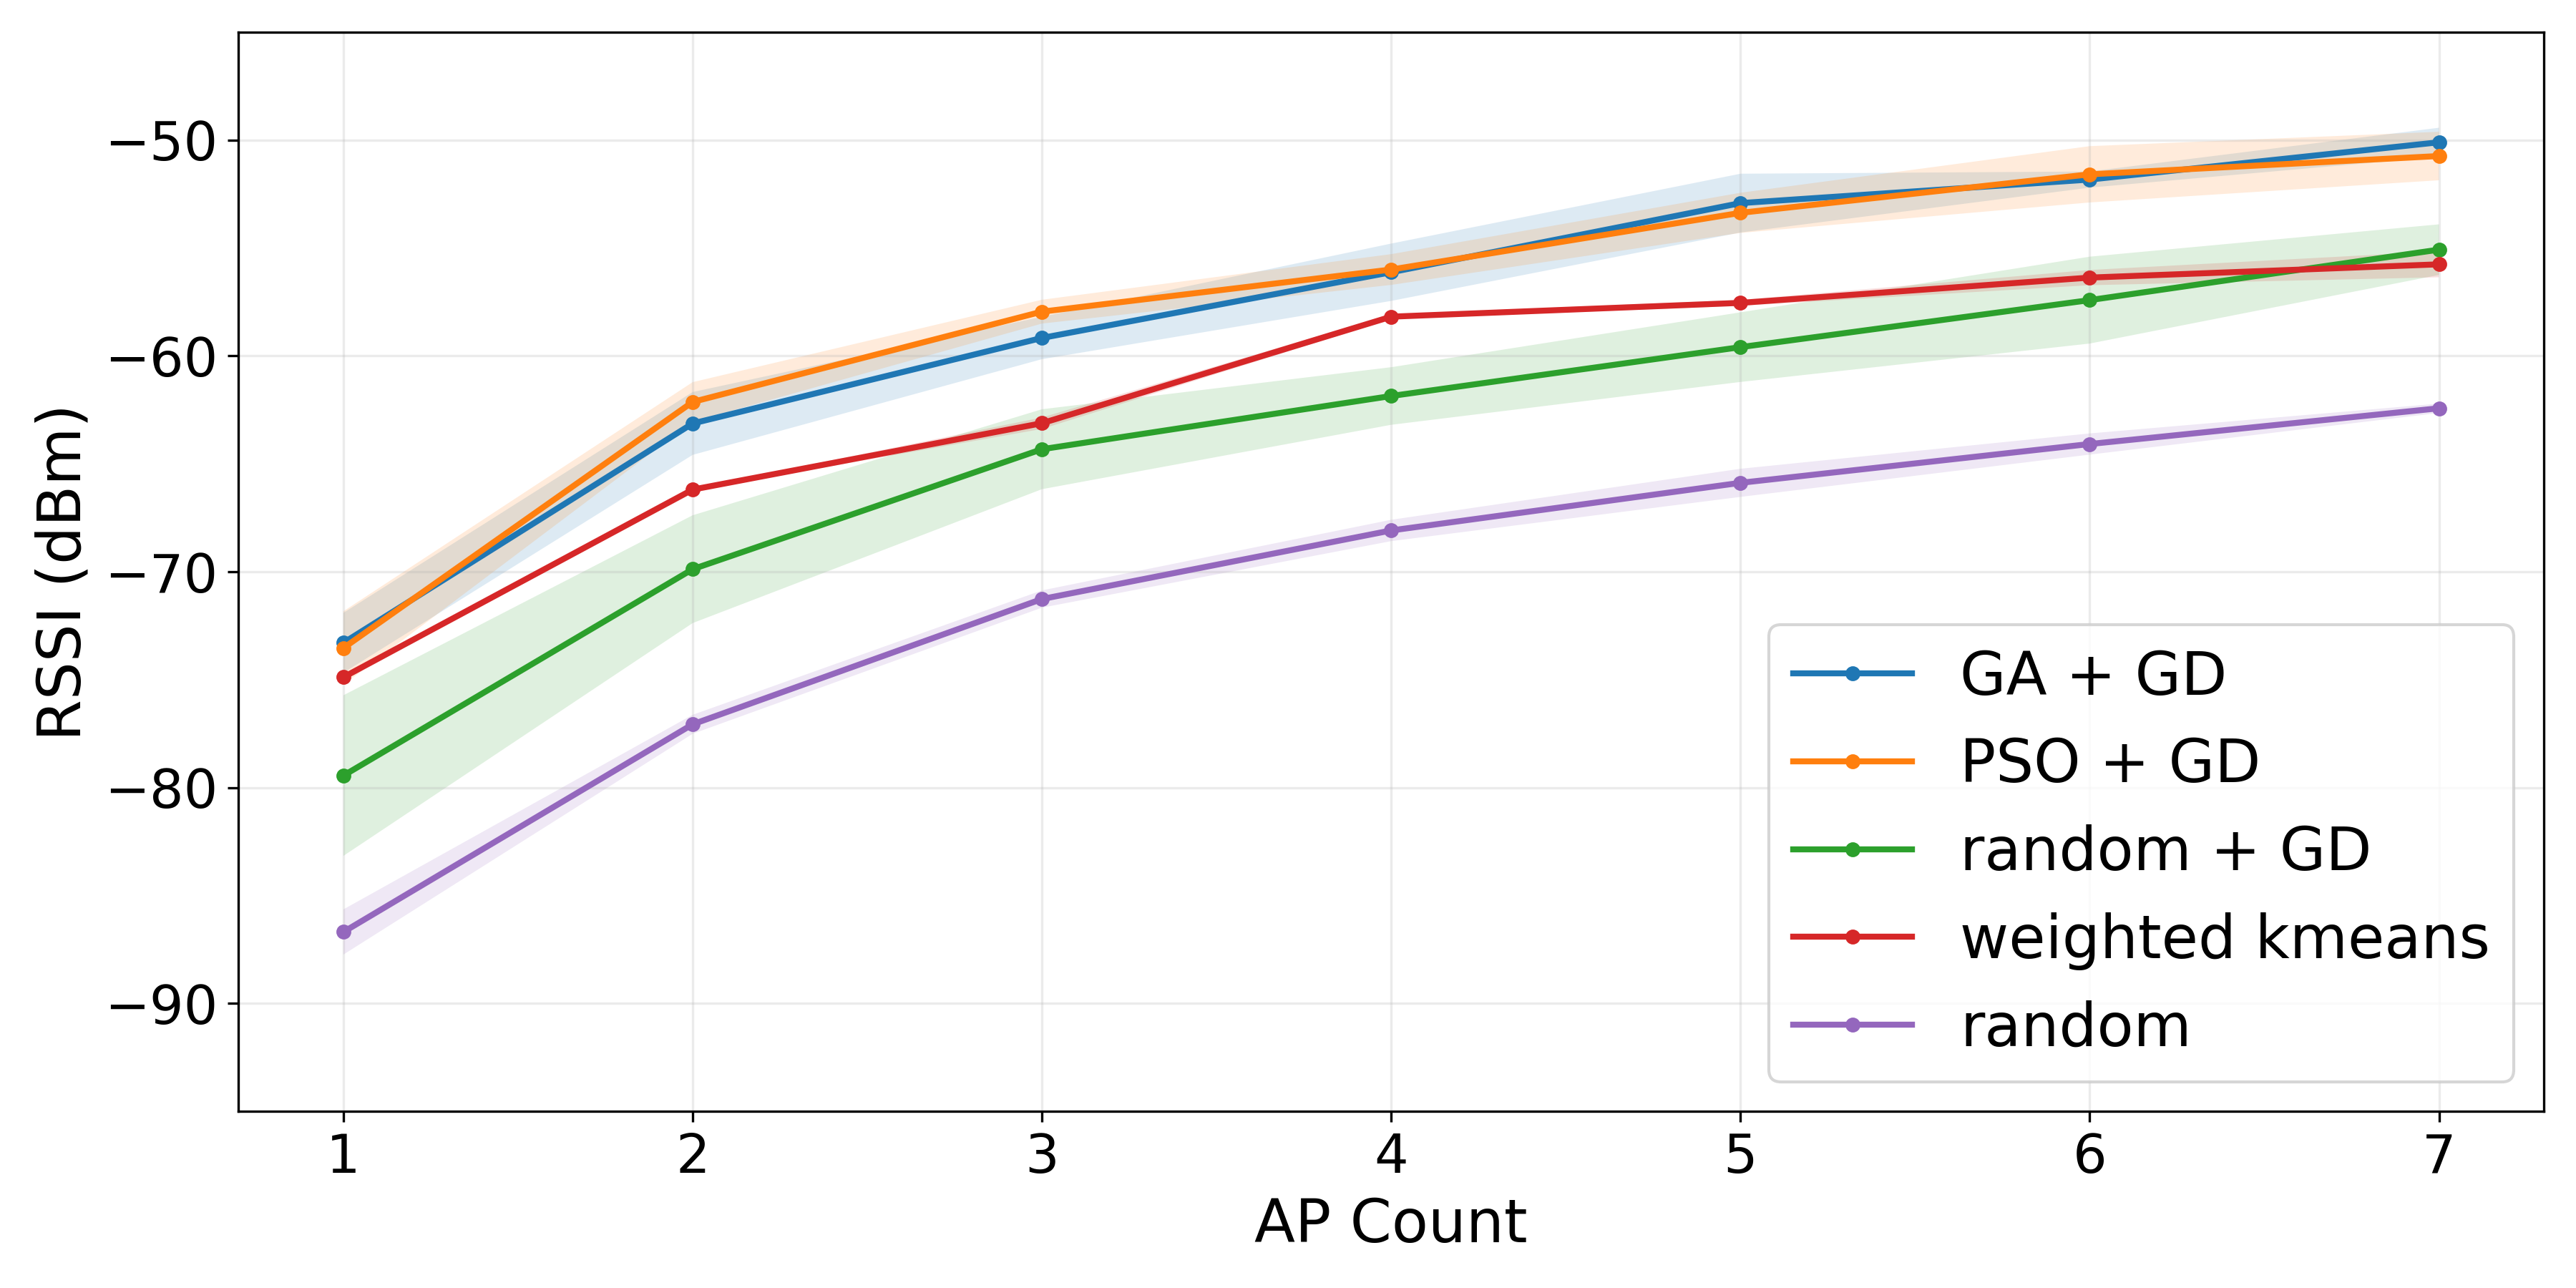

## Plot: elbow_priority_mean_rss_dbm.png

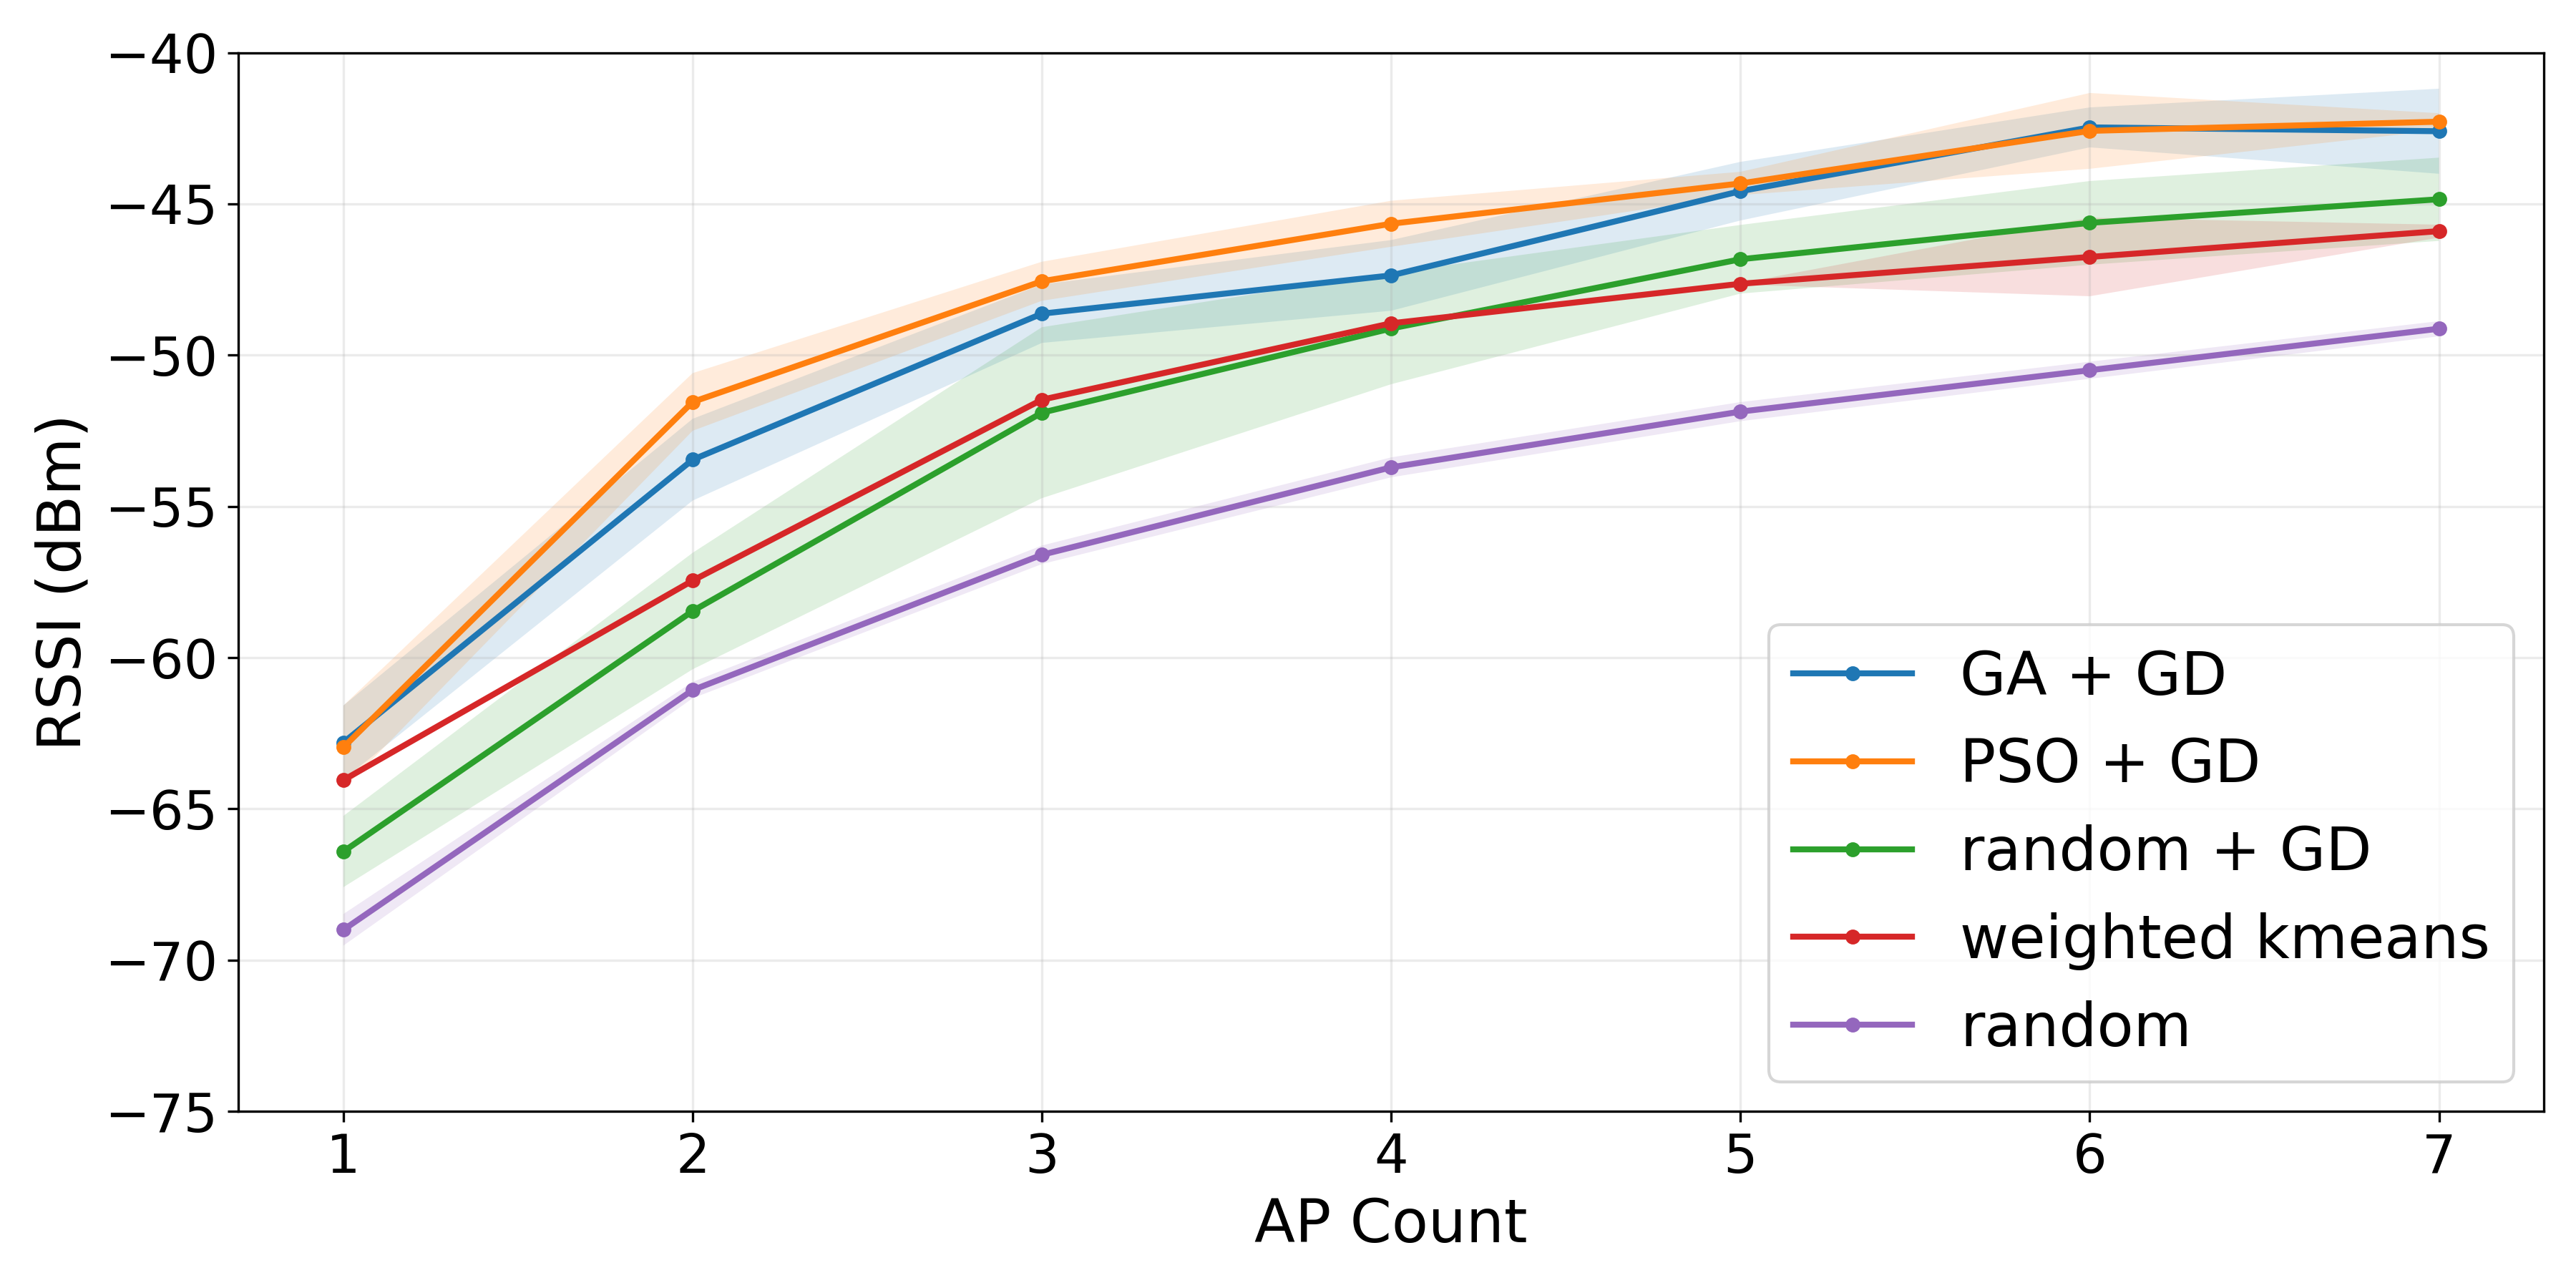

## Plot: elbow_priority_min_rss_dbm.png

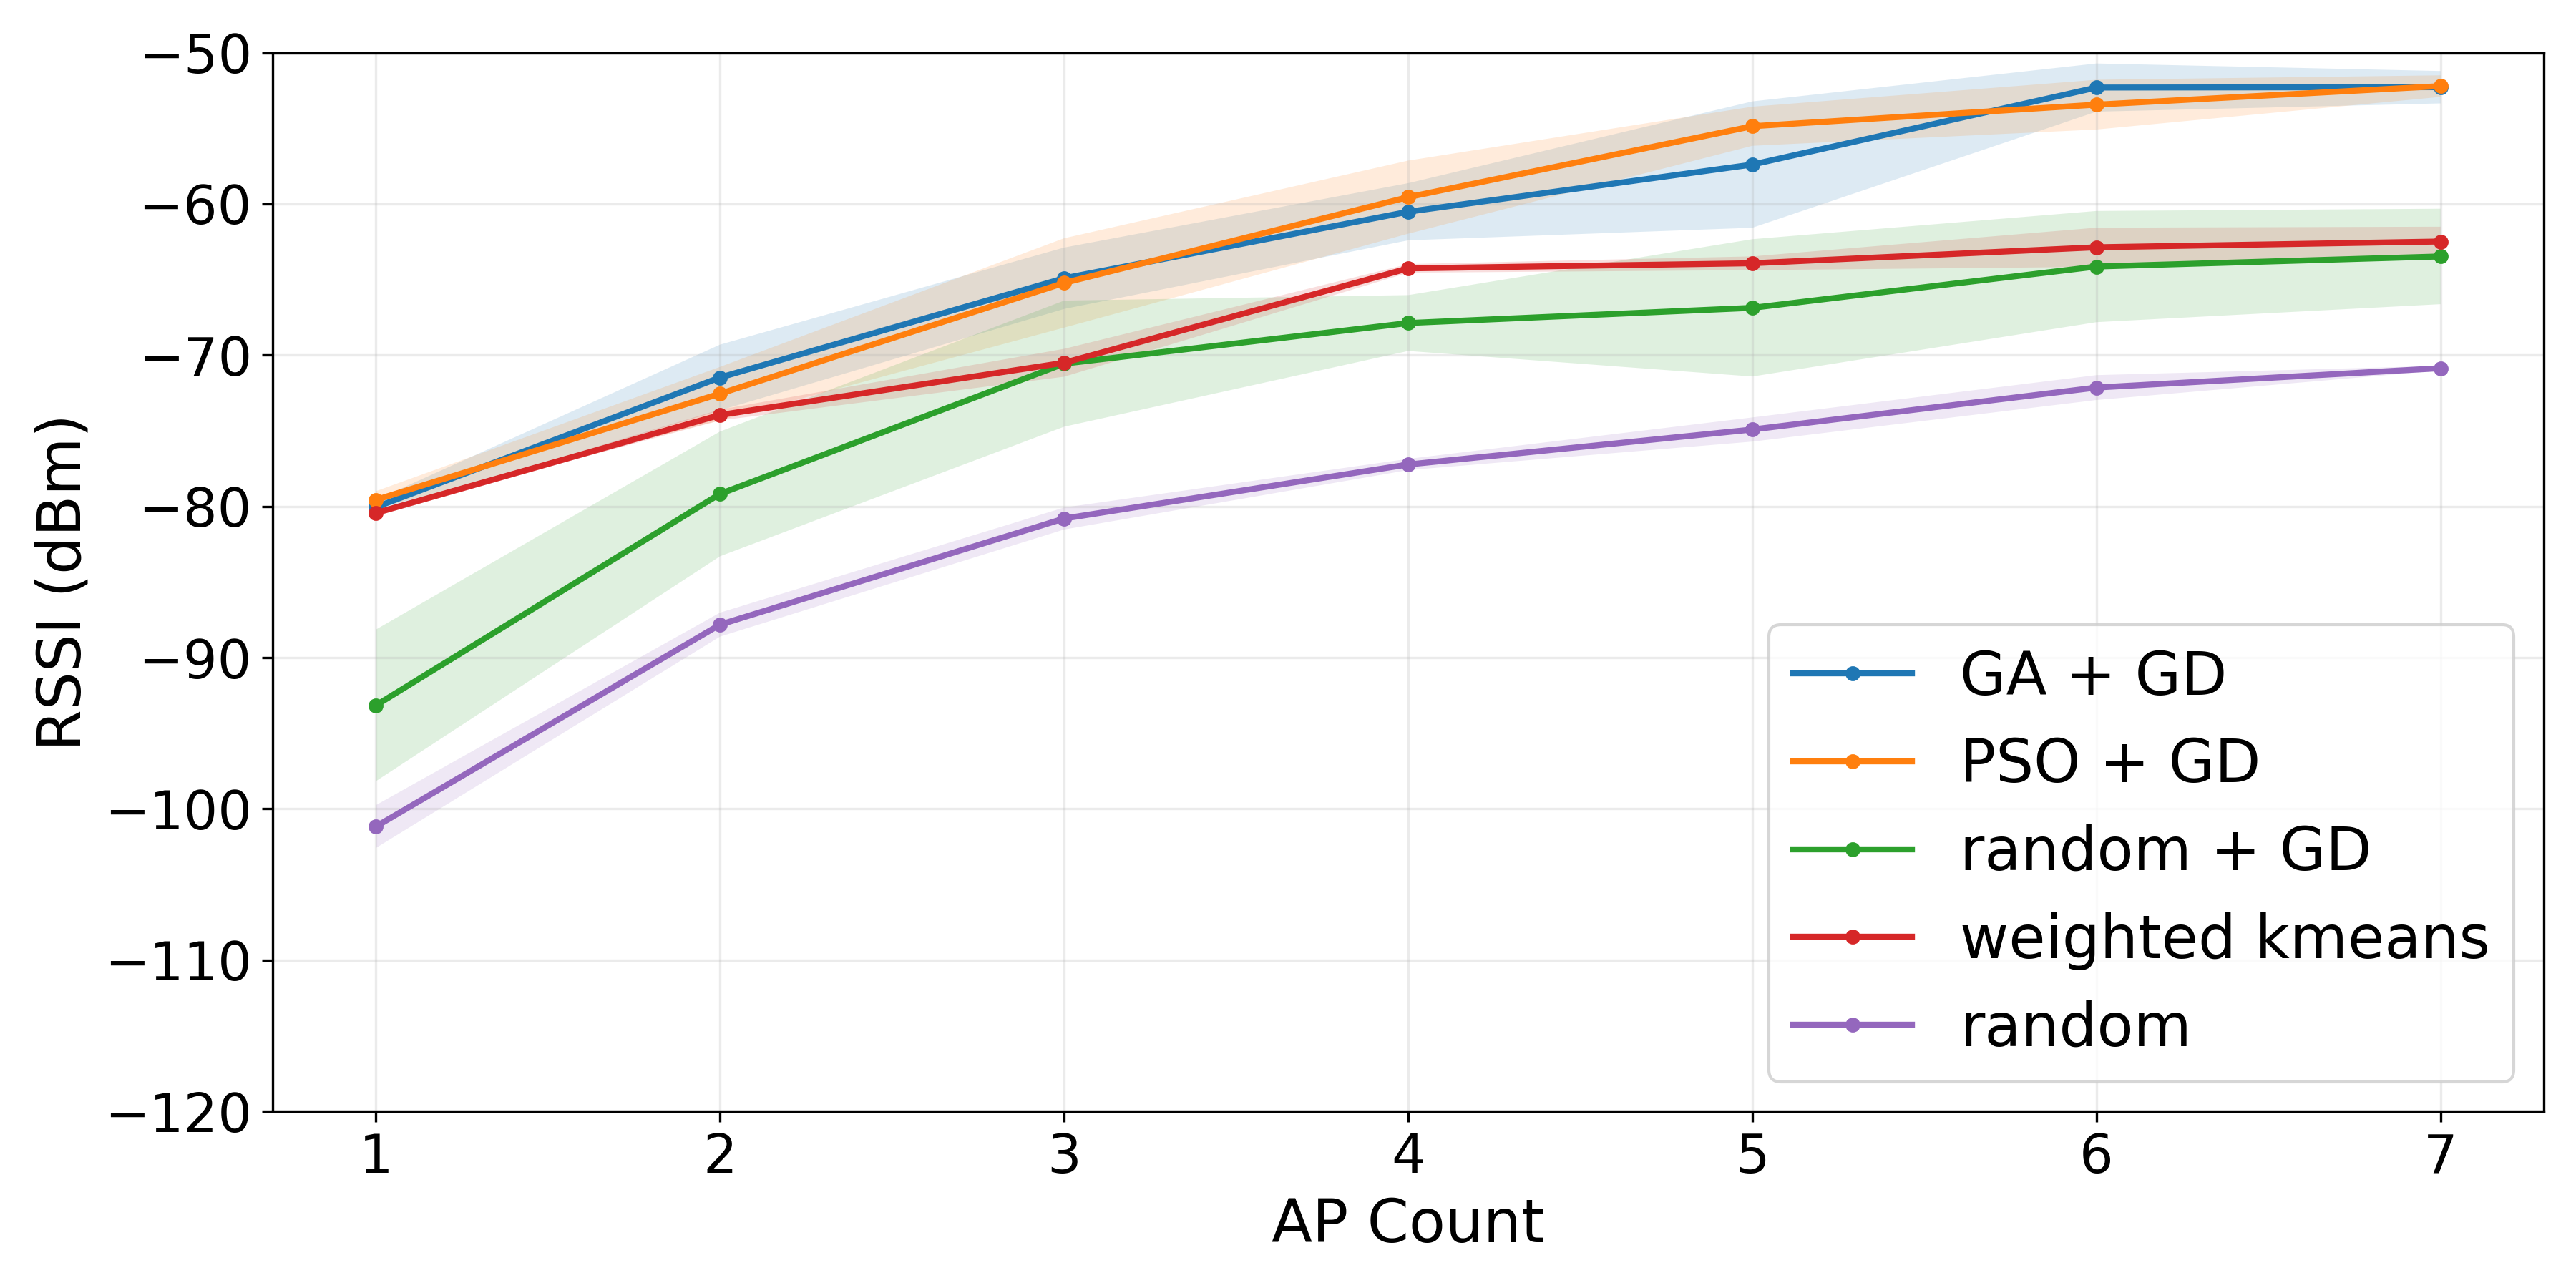

## Plot: elbow_priority_p5_rss_dbm.png

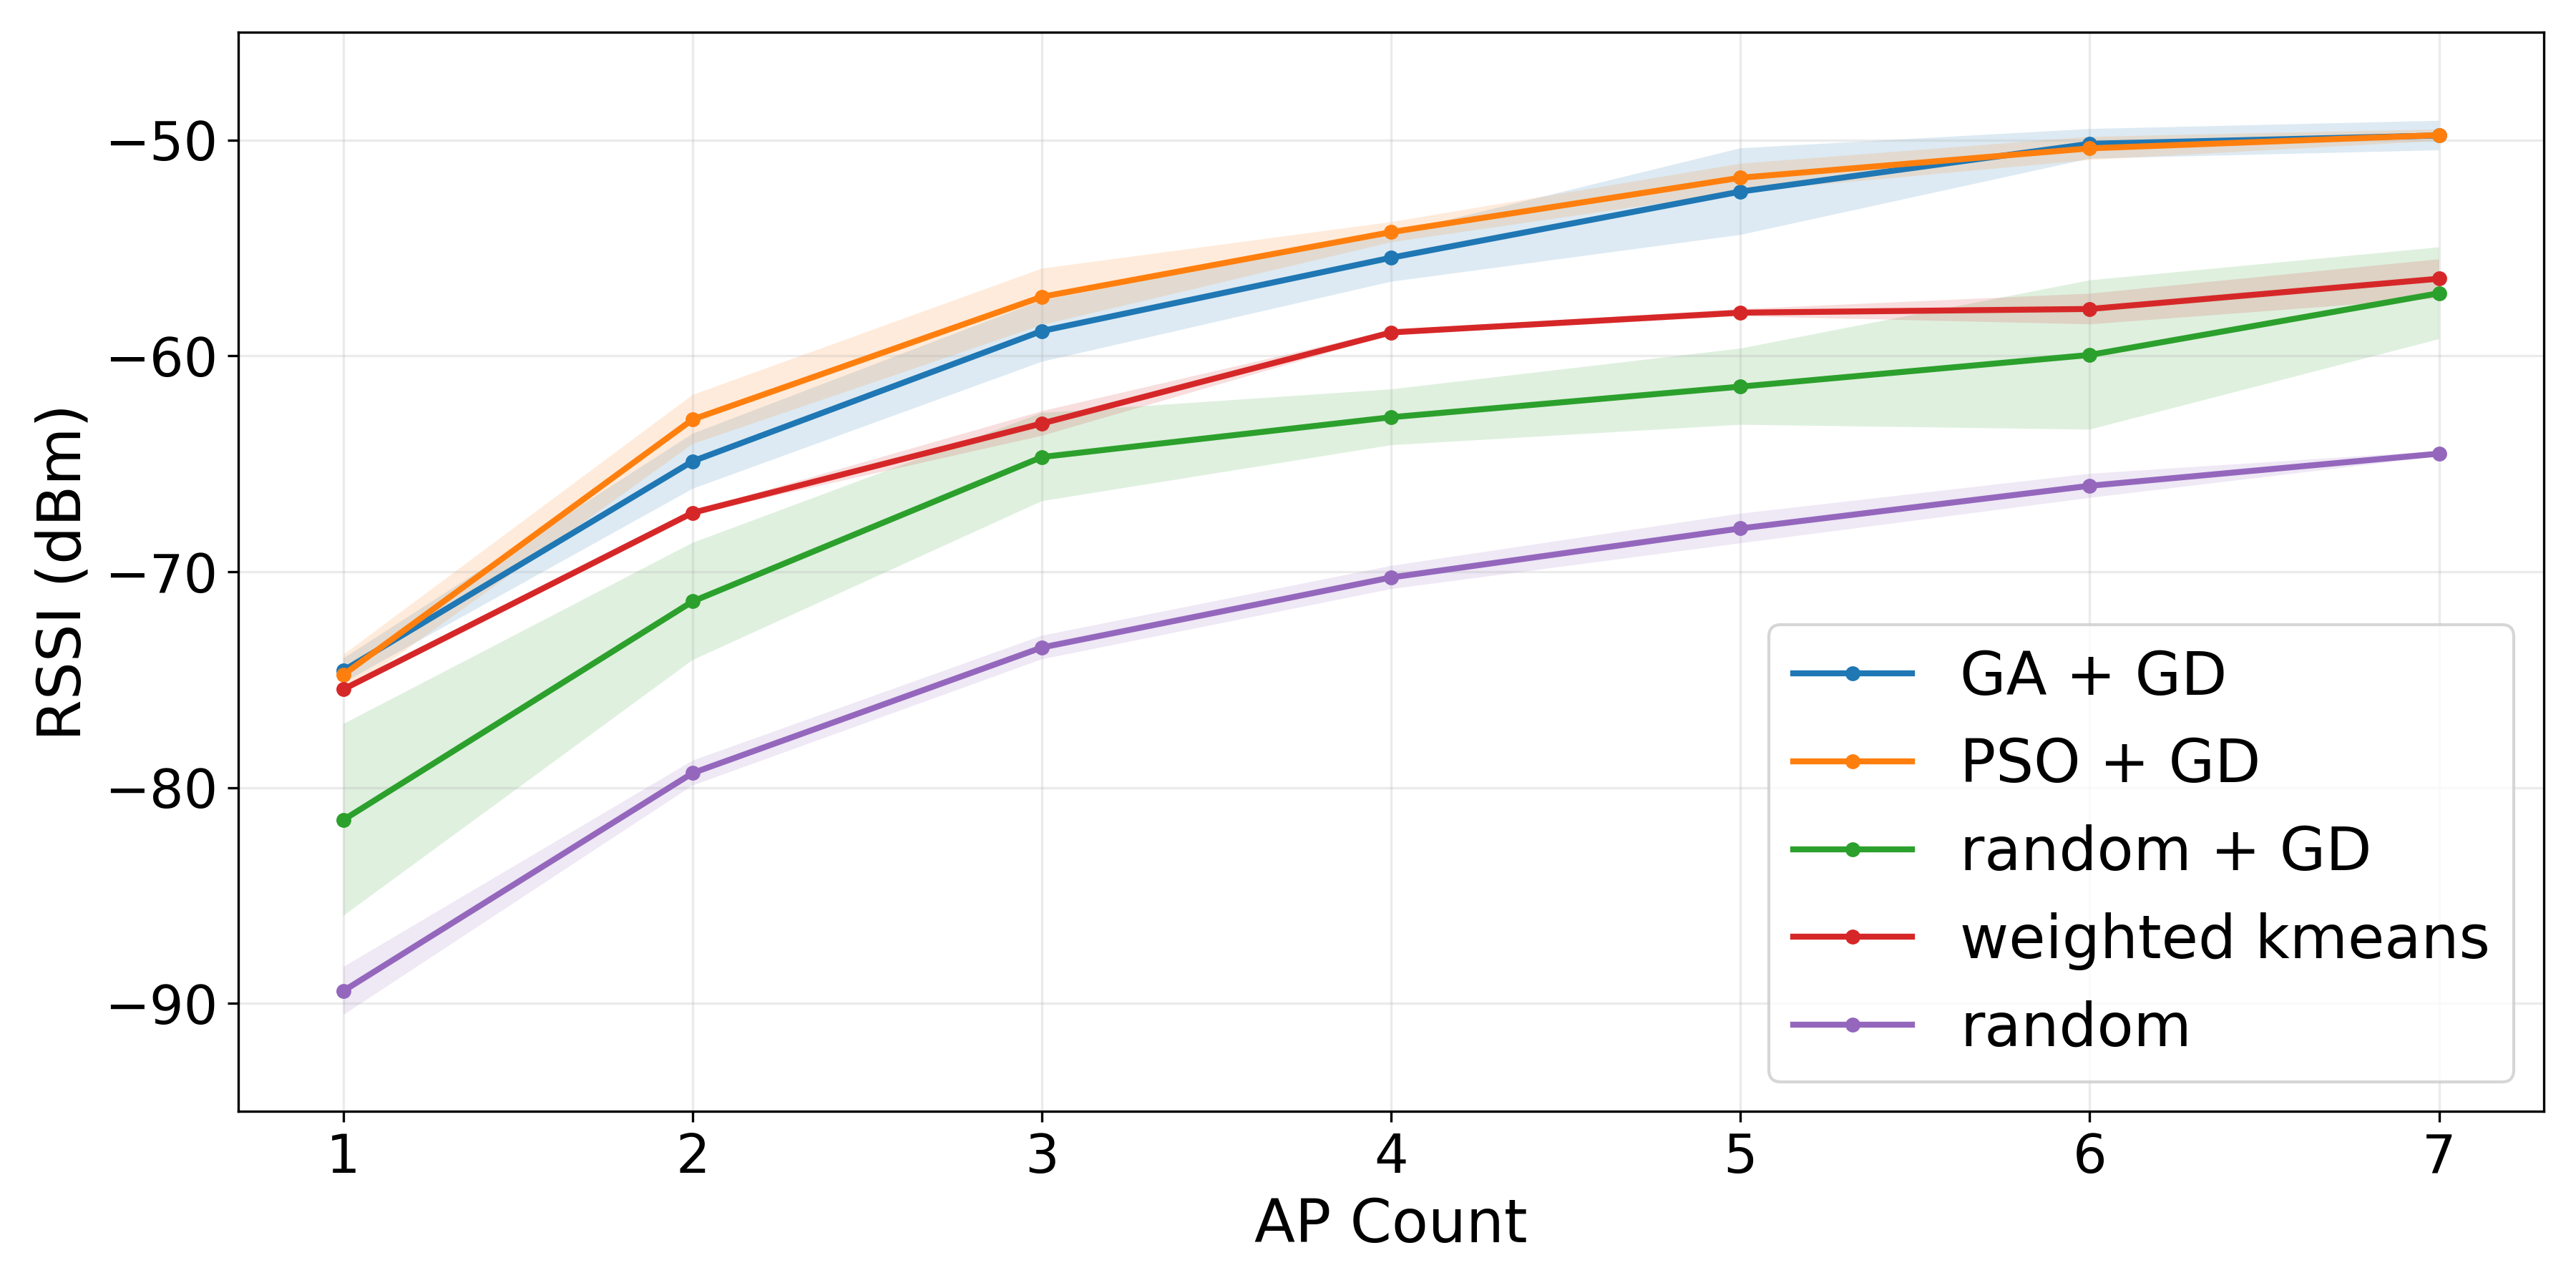

In [6]:
# Recreate all elbow figures, display them inline, and print tables per method
elbow_data = load_elbow_data(DATA_PATH)

metric_order = [
    "primary_loss",
    "mean_rss_dbm",
    "min_rss_dbm",
    "p5_rss_dbm",
    "priority_mean_rss_dbm",
    "priority_min_rss_dbm",
    "priority_p5_rss_dbm",
]

# Optional method ordering for visual consistency across all figures and tables
method_order = ["memetic", "pso_gd", "random_gd", "weighted_kmeans", "random"]

# Optional fixed y-axis ranges per metric for cross-scenario comparisons.
# Use None to fall back to metric_payload["y_limits"] if available.
metric_y_axis_ranges: dict[str, tuple[float, float] | None] = {
    "primary_loss": None,
    "mean_rss_dbm": (-75, -40),
    "min_rss_dbm": (-120, -50),
    "p5_rss_dbm": (-95, -45),
    "priority_mean_rss_dbm": (-75, -40),
    "priority_min_rss_dbm": (-120, -50),
    "priority_p5_rss_dbm": (-95, -45),
}
# Example fixed ranges:
# metric_y_axis_ranges["mean_rss_dbm"] = (-85.0, -50.0)
# metric_y_axis_ranges["priority_mean_rss_dbm"] = (-90.0, -55.0)

# Optional override for mean_rss_dbm -> kmeans -> mean.
# Keep as None to disable, or provide a full replacement list.
kmeans_mean_override = None
# Example:
# kmeans_mean_override = [-67.5, -66.9, -66.2, -65.8, -65.3]

saved_paths = []
for metric_key in metric_order:
    metric_payload = elbow_data.get(metric_key)
    if not isinstance(metric_payload, Mapping):
        print(f"Skipping missing or invalid metric: {metric_key}")
        continue

    y_axis_range = metric_y_axis_ranges.get(metric_key)
    saved_path = plot_elbow_metric(
        metric_key=metric_key,
        metric_payload=metric_payload,
        output_dir=OUTPUT_DIR,
        with_error_band=True,
        method_order=method_order,
        y_axis_range=y_axis_range,
    )
    saved_paths.append(saved_path)
    print(f"Saved: {saved_path}")
    if y_axis_range is not None:
        print(f"Applied y-axis range for {metric_key}: ({float(y_axis_range[0])}, {float(y_axis_range[1])})")

print(f"\nGenerated {len(saved_paths)} elbow plot(s) in {OUTPUT_DIR}")

display(Markdown("# Generated Elbow Plots"))
display_saved_plots(saved_paths)

Saved: /home/hieule/research/reflector-position/tmp_comparison_results1/office/plots/elbow-fixed/elbow_primary_loss.png
Saved: /home/hieule/research/reflector-position/tmp_comparison_results1/office/plots/elbow-fixed/elbow_mean_rss_dbm.png
Applied y-axis range for mean_rss_dbm: (-75.0, -40.0)
Saved: /home/hieule/research/reflector-position/tmp_comparison_results1/office/plots/elbow-fixed/elbow_min_rss_dbm.png
Applied y-axis range for min_rss_dbm: (-120.0, -50.0)
Saved: /home/hieule/research/reflector-position/tmp_comparison_results1/office/plots/elbow-fixed/elbow_p5_rss_dbm.png
Applied y-axis range for p5_rss_dbm: (-95.0, -45.0)
Saved: /home/hieule/research/reflector-position/tmp_comparison_results1/office/plots/elbow-fixed/elbow_priority_mean_rss_dbm.png
Applied y-axis range for priority_mean_rss_dbm: (-75.0, -40.0)
Saved: /home/hieule/research/reflector-position/tmp_comparison_results1/office/plots/elbow-fixed/elbow_priority_min_rss_dbm.png
Applied y-axis range for priority_min_rss_d

# Generated Elbow Plots

## Plot: elbow_primary_loss.png

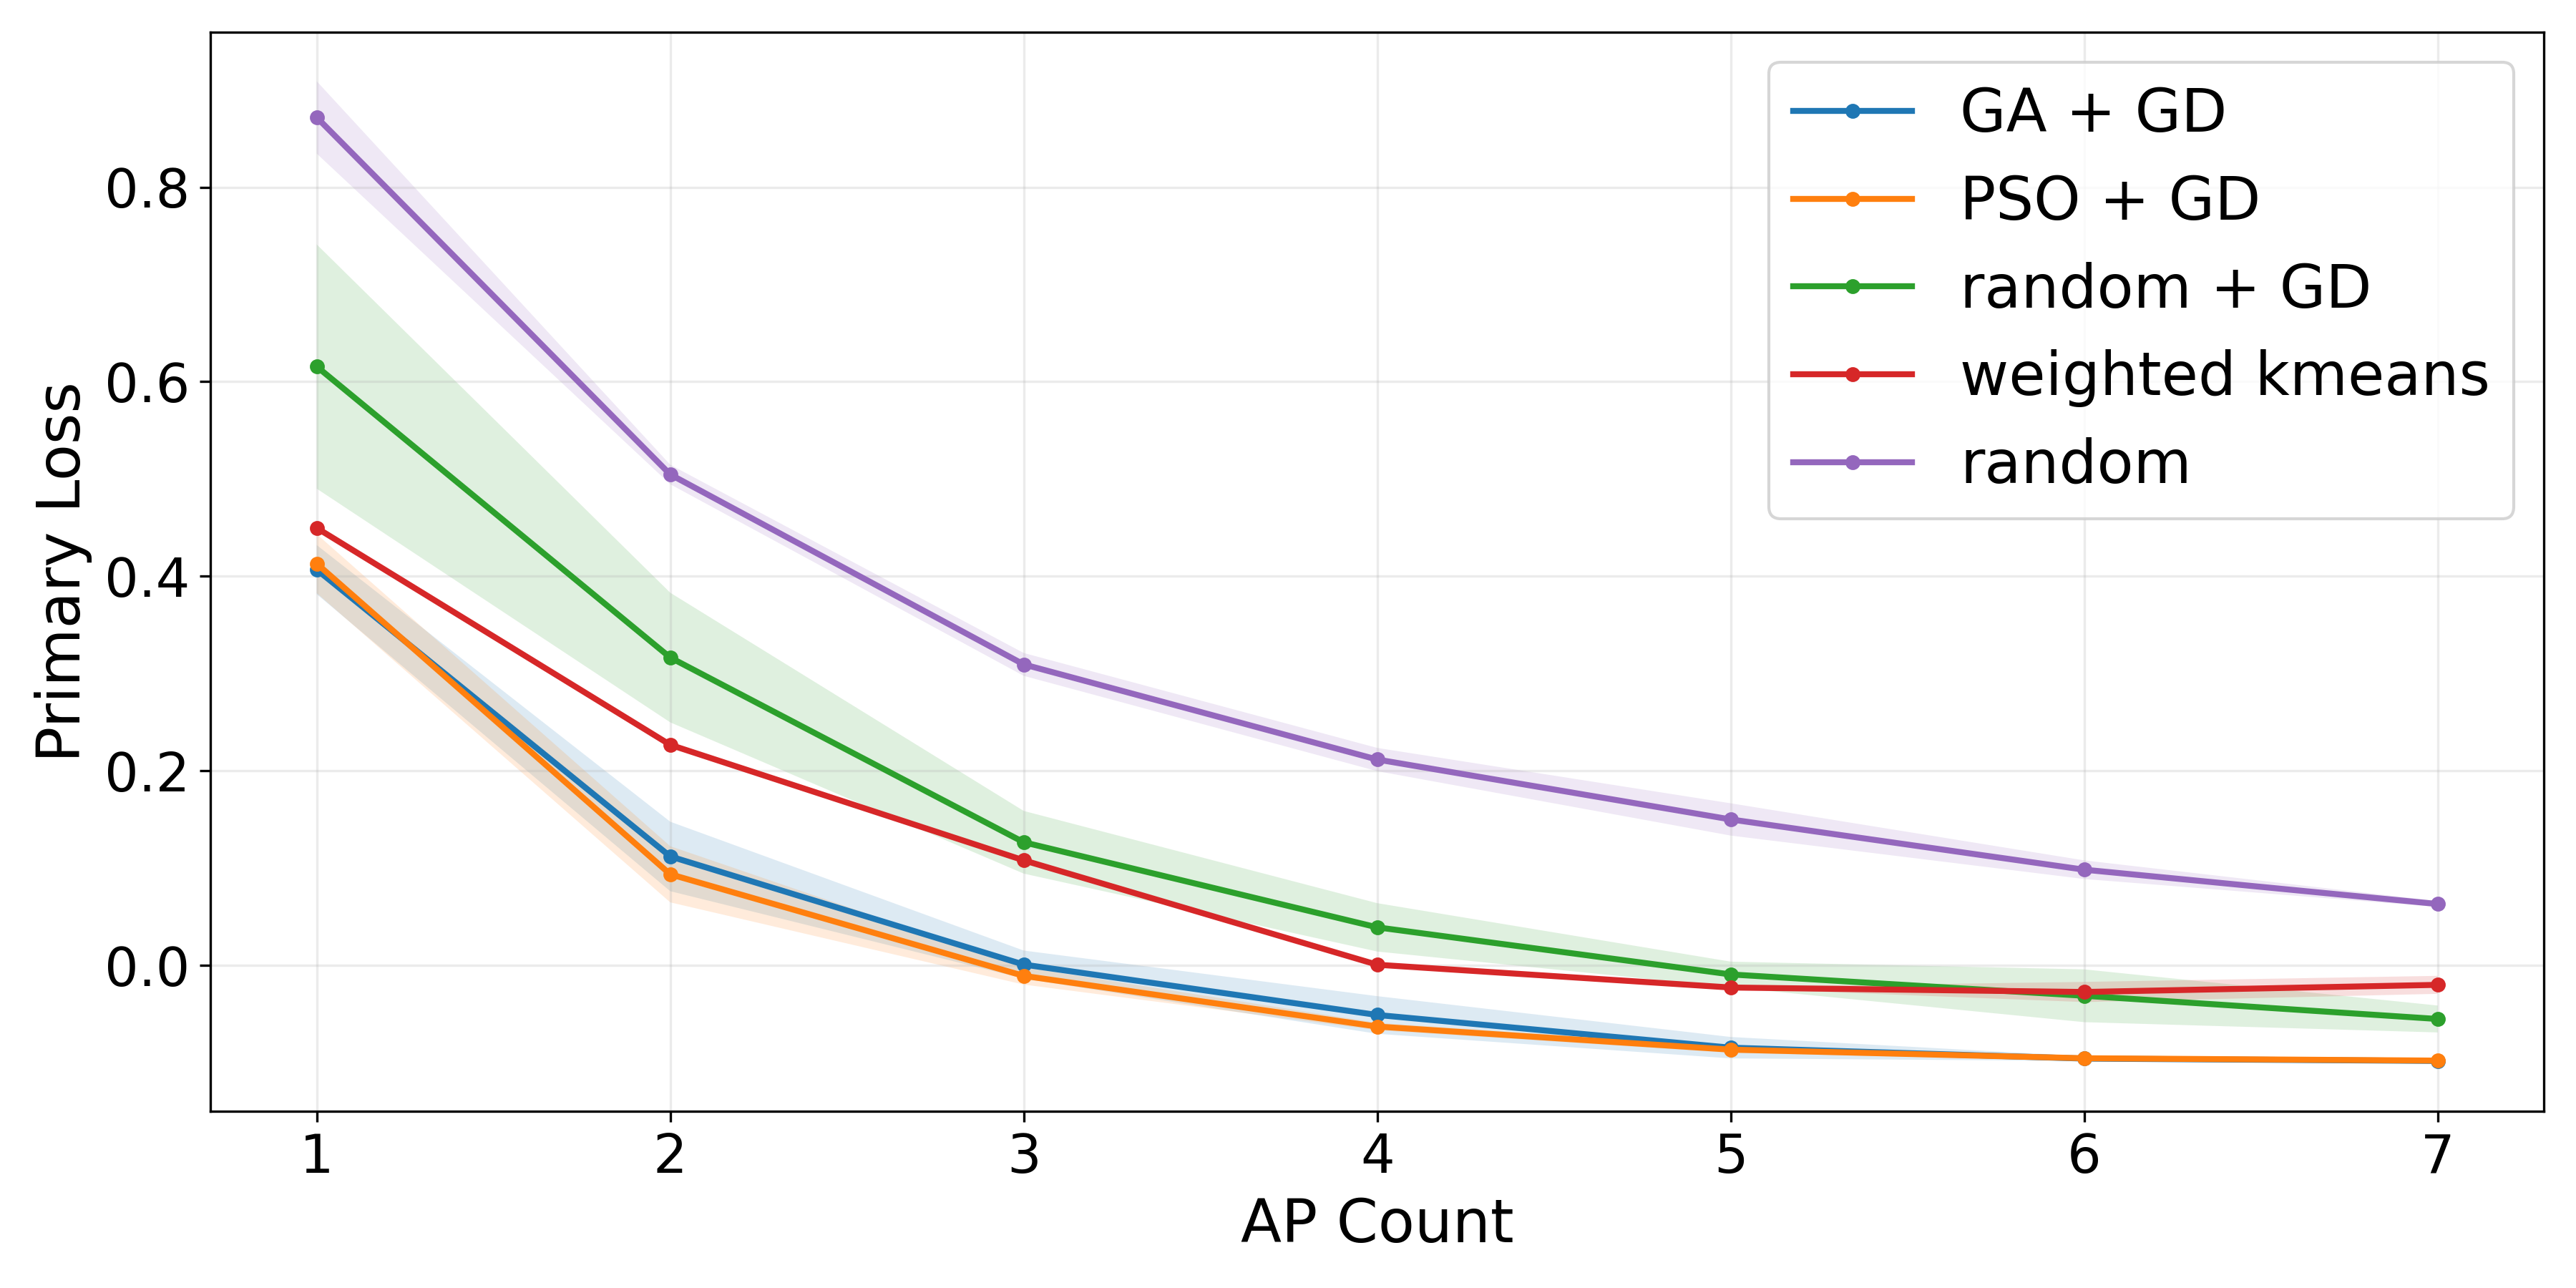

## Plot: elbow_mean_rss_dbm.png

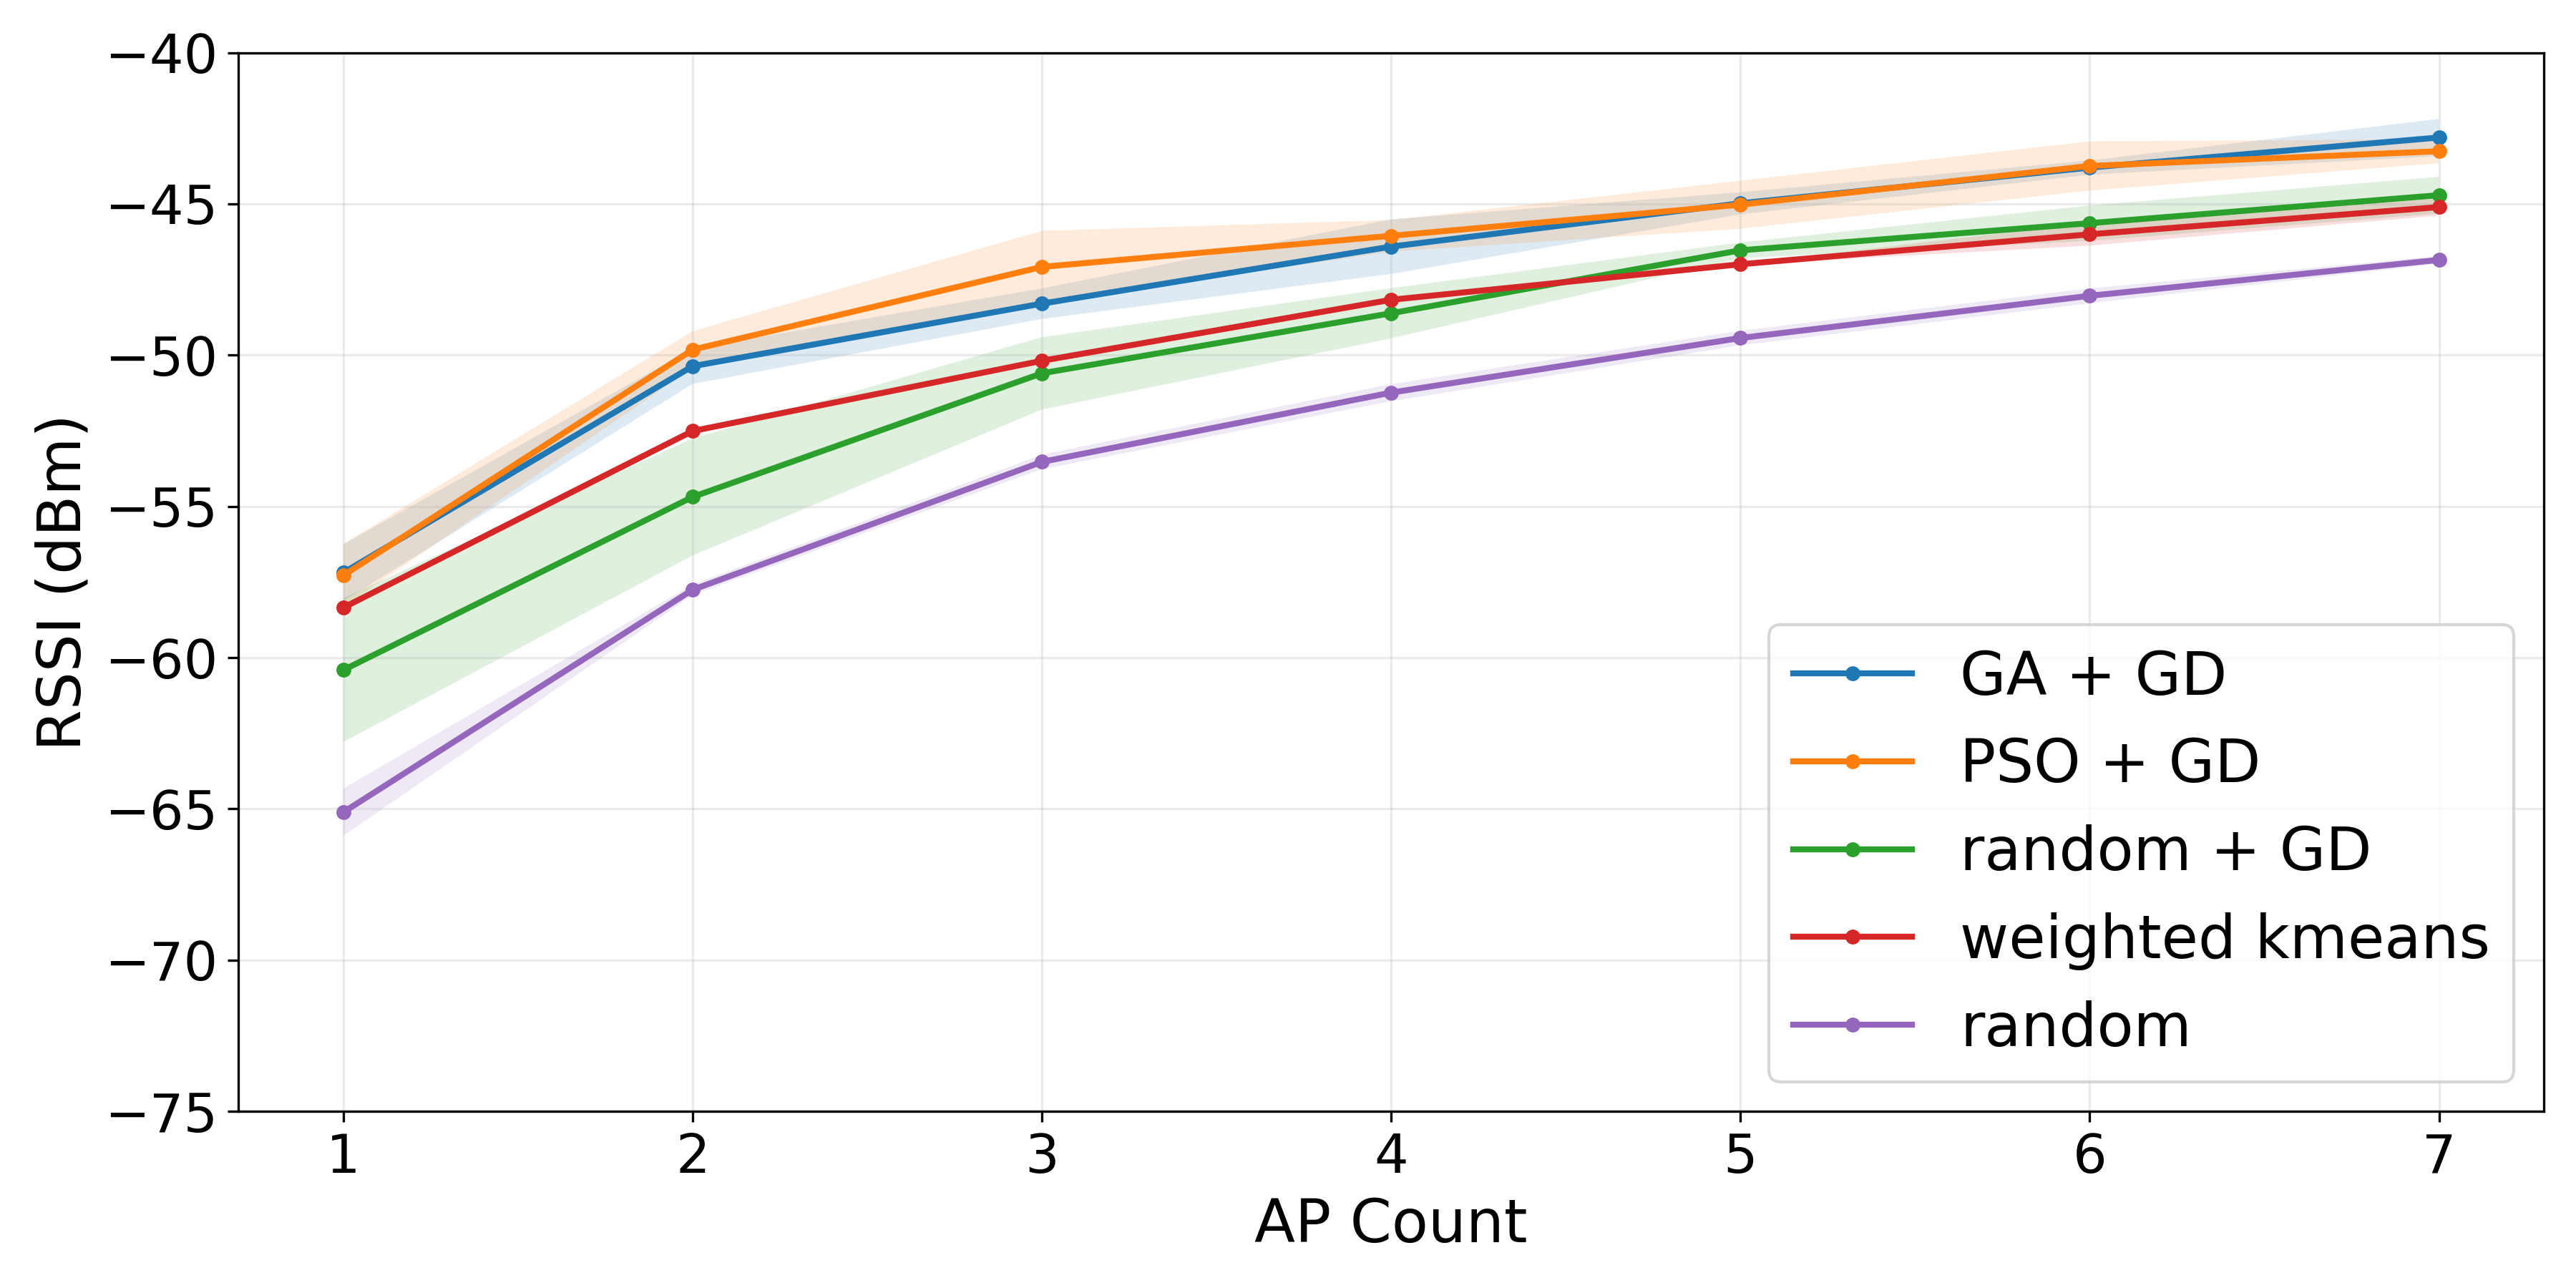

## Plot: elbow_min_rss_dbm.png

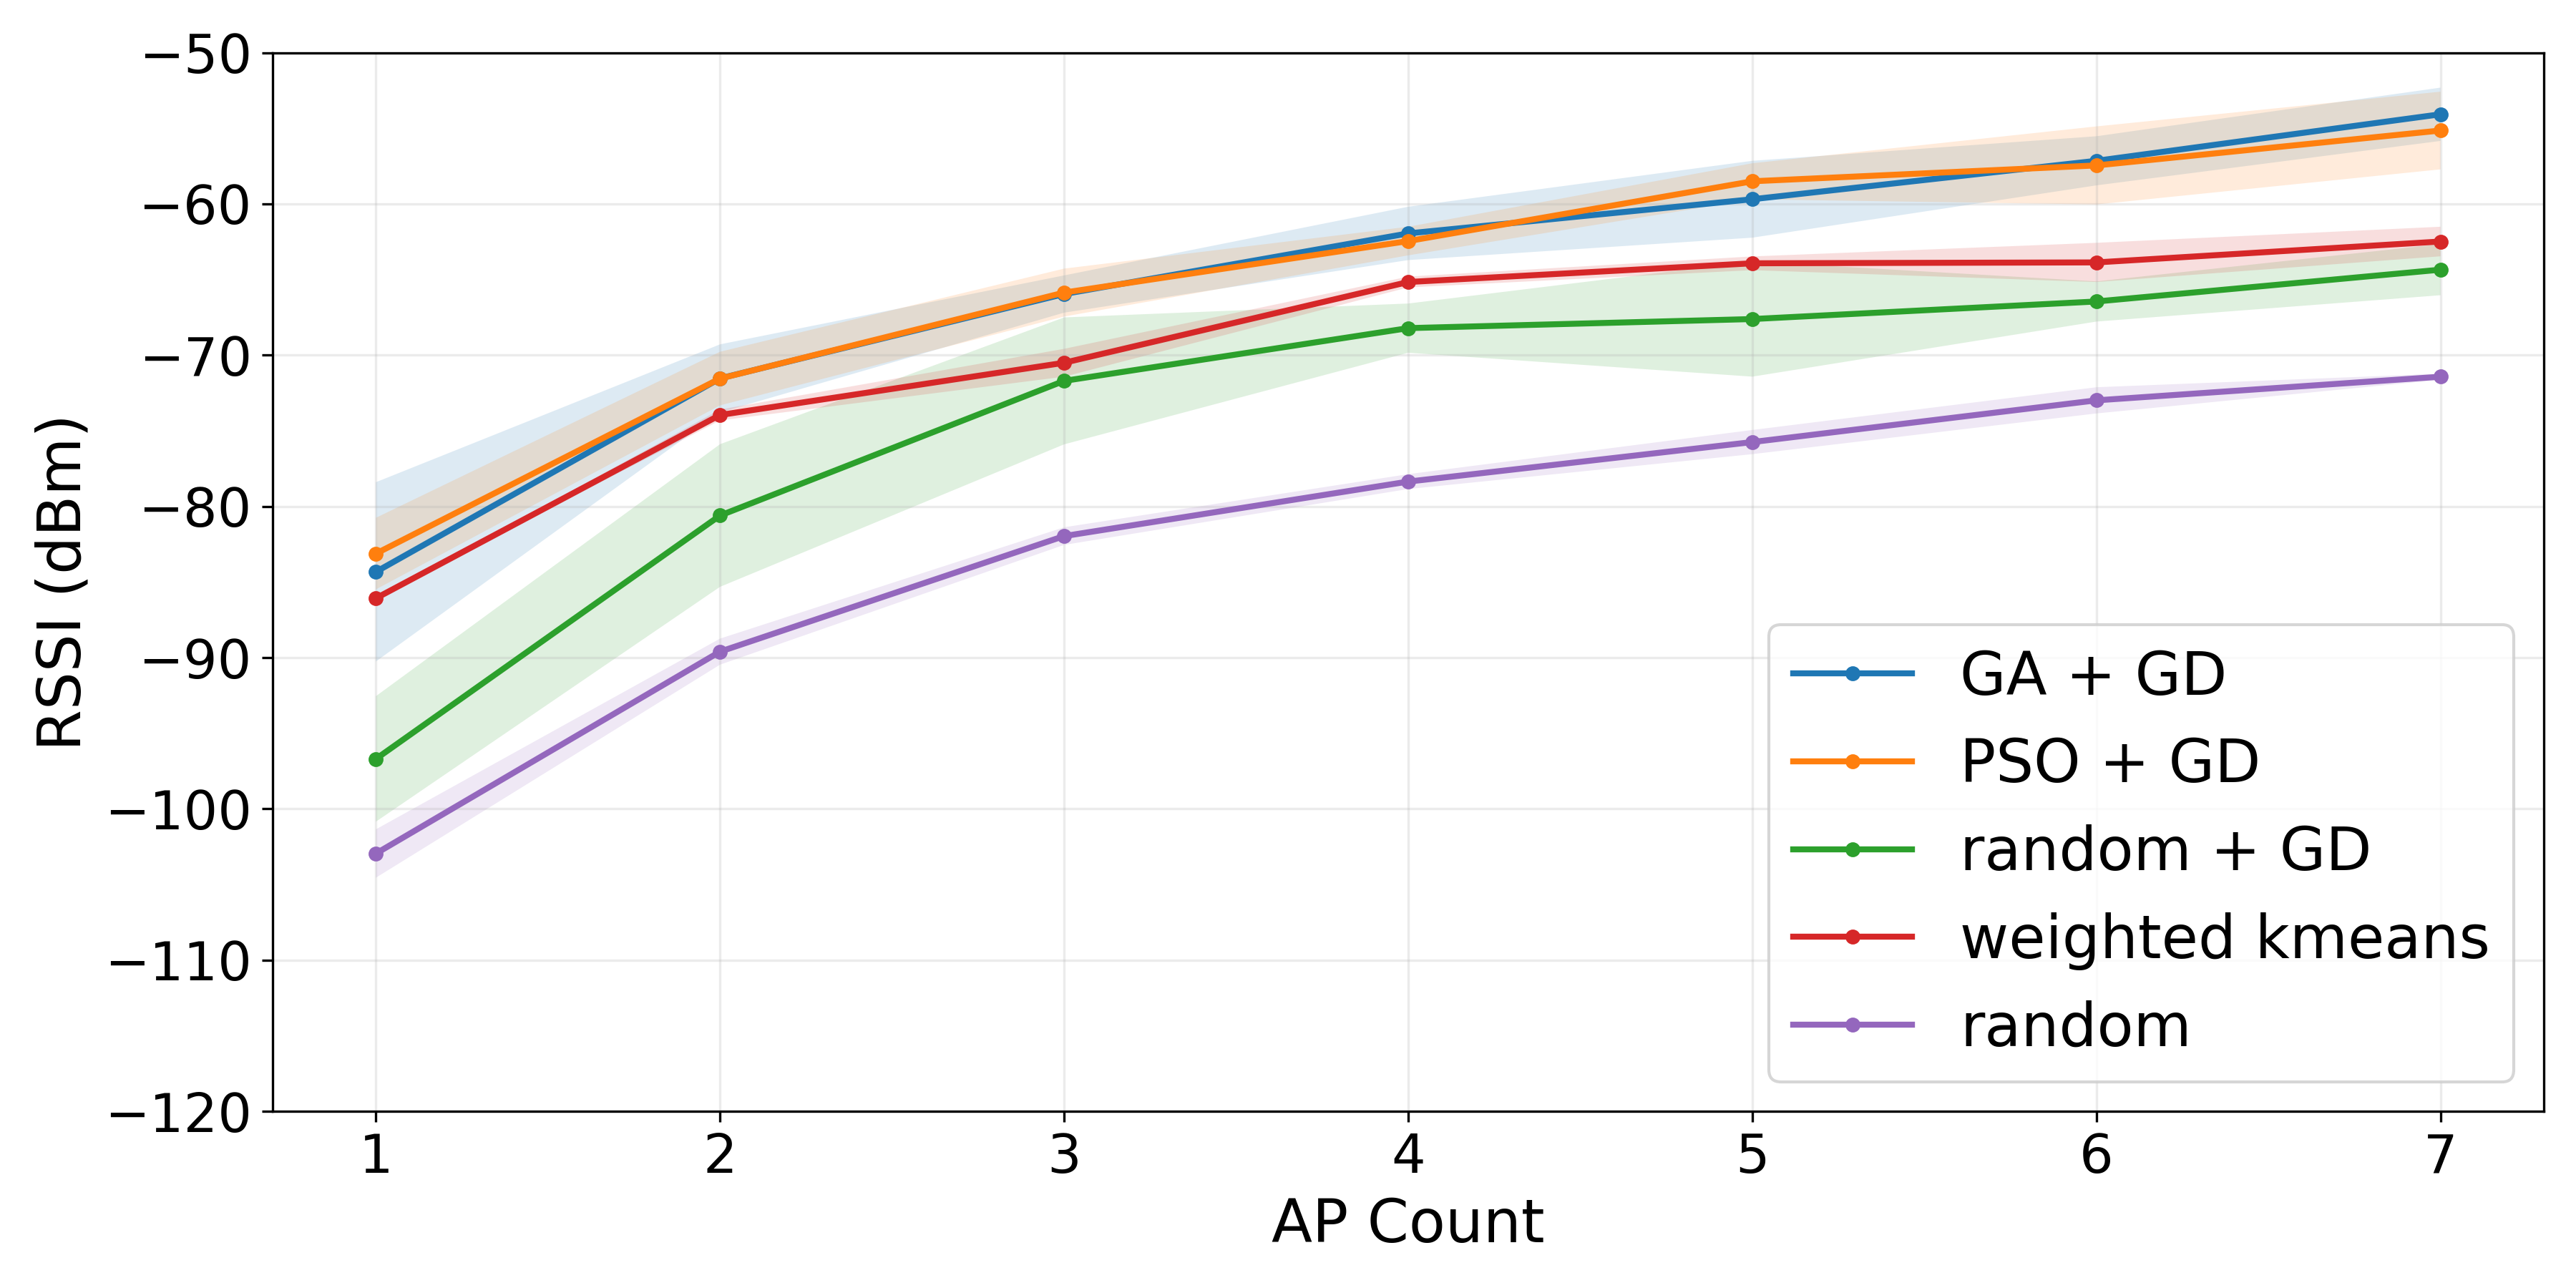

## Plot: elbow_p5_rss_dbm.png

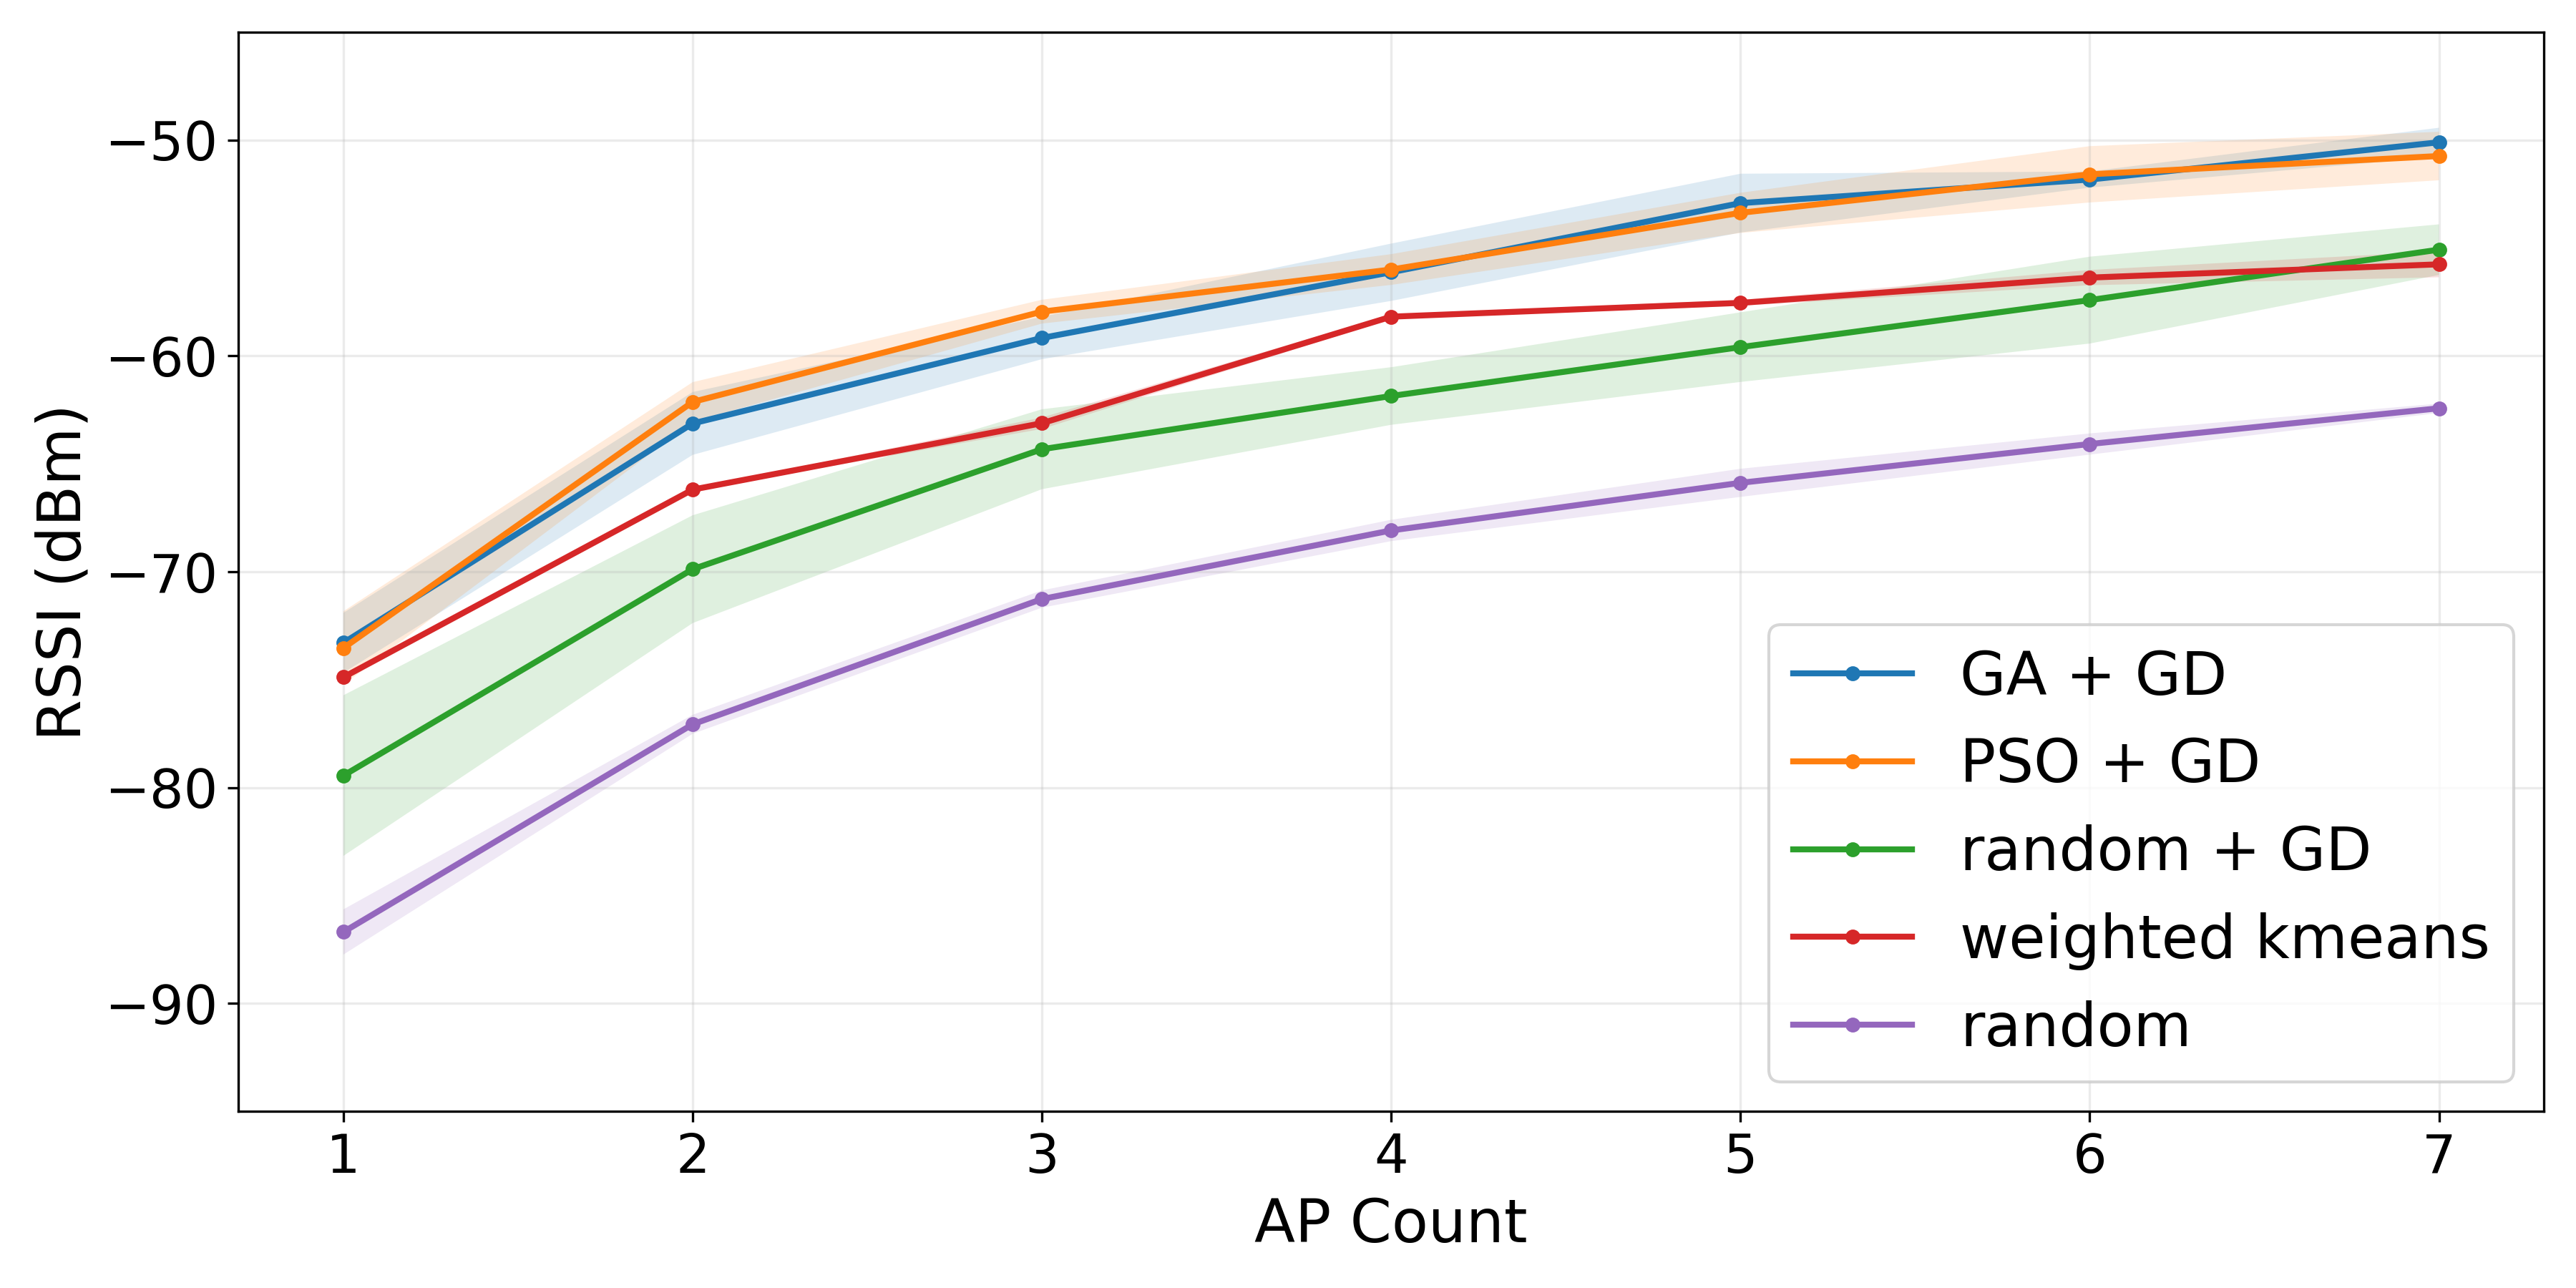

## Plot: elbow_priority_mean_rss_dbm.png

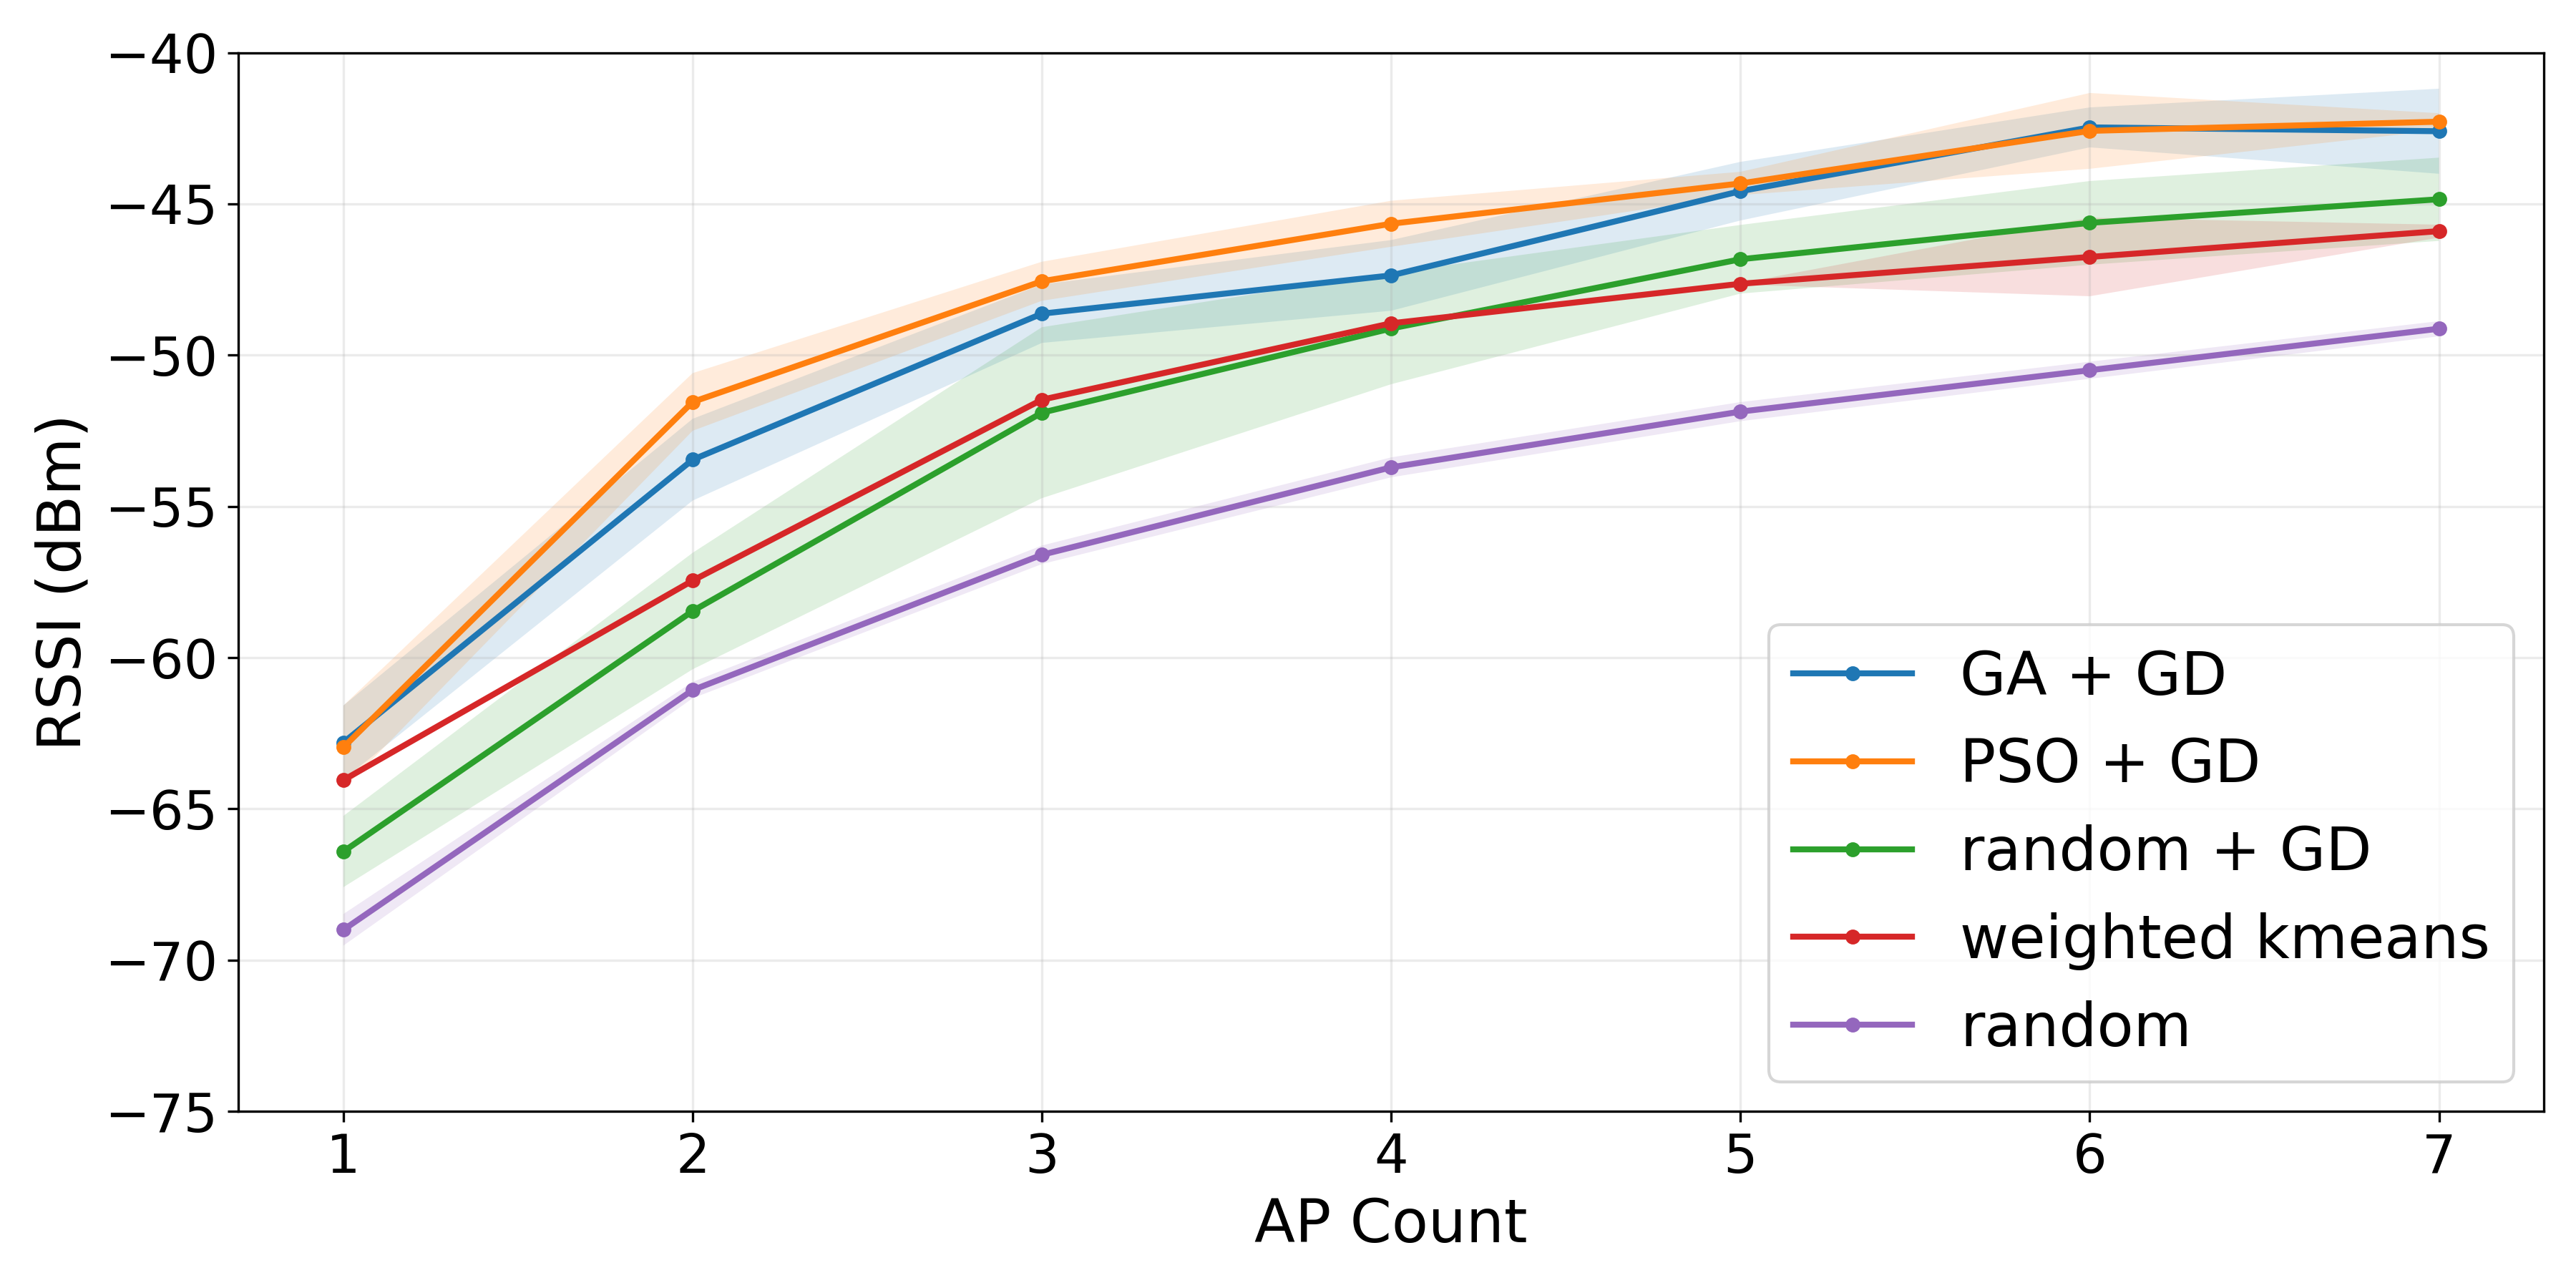

## Plot: elbow_priority_min_rss_dbm.png

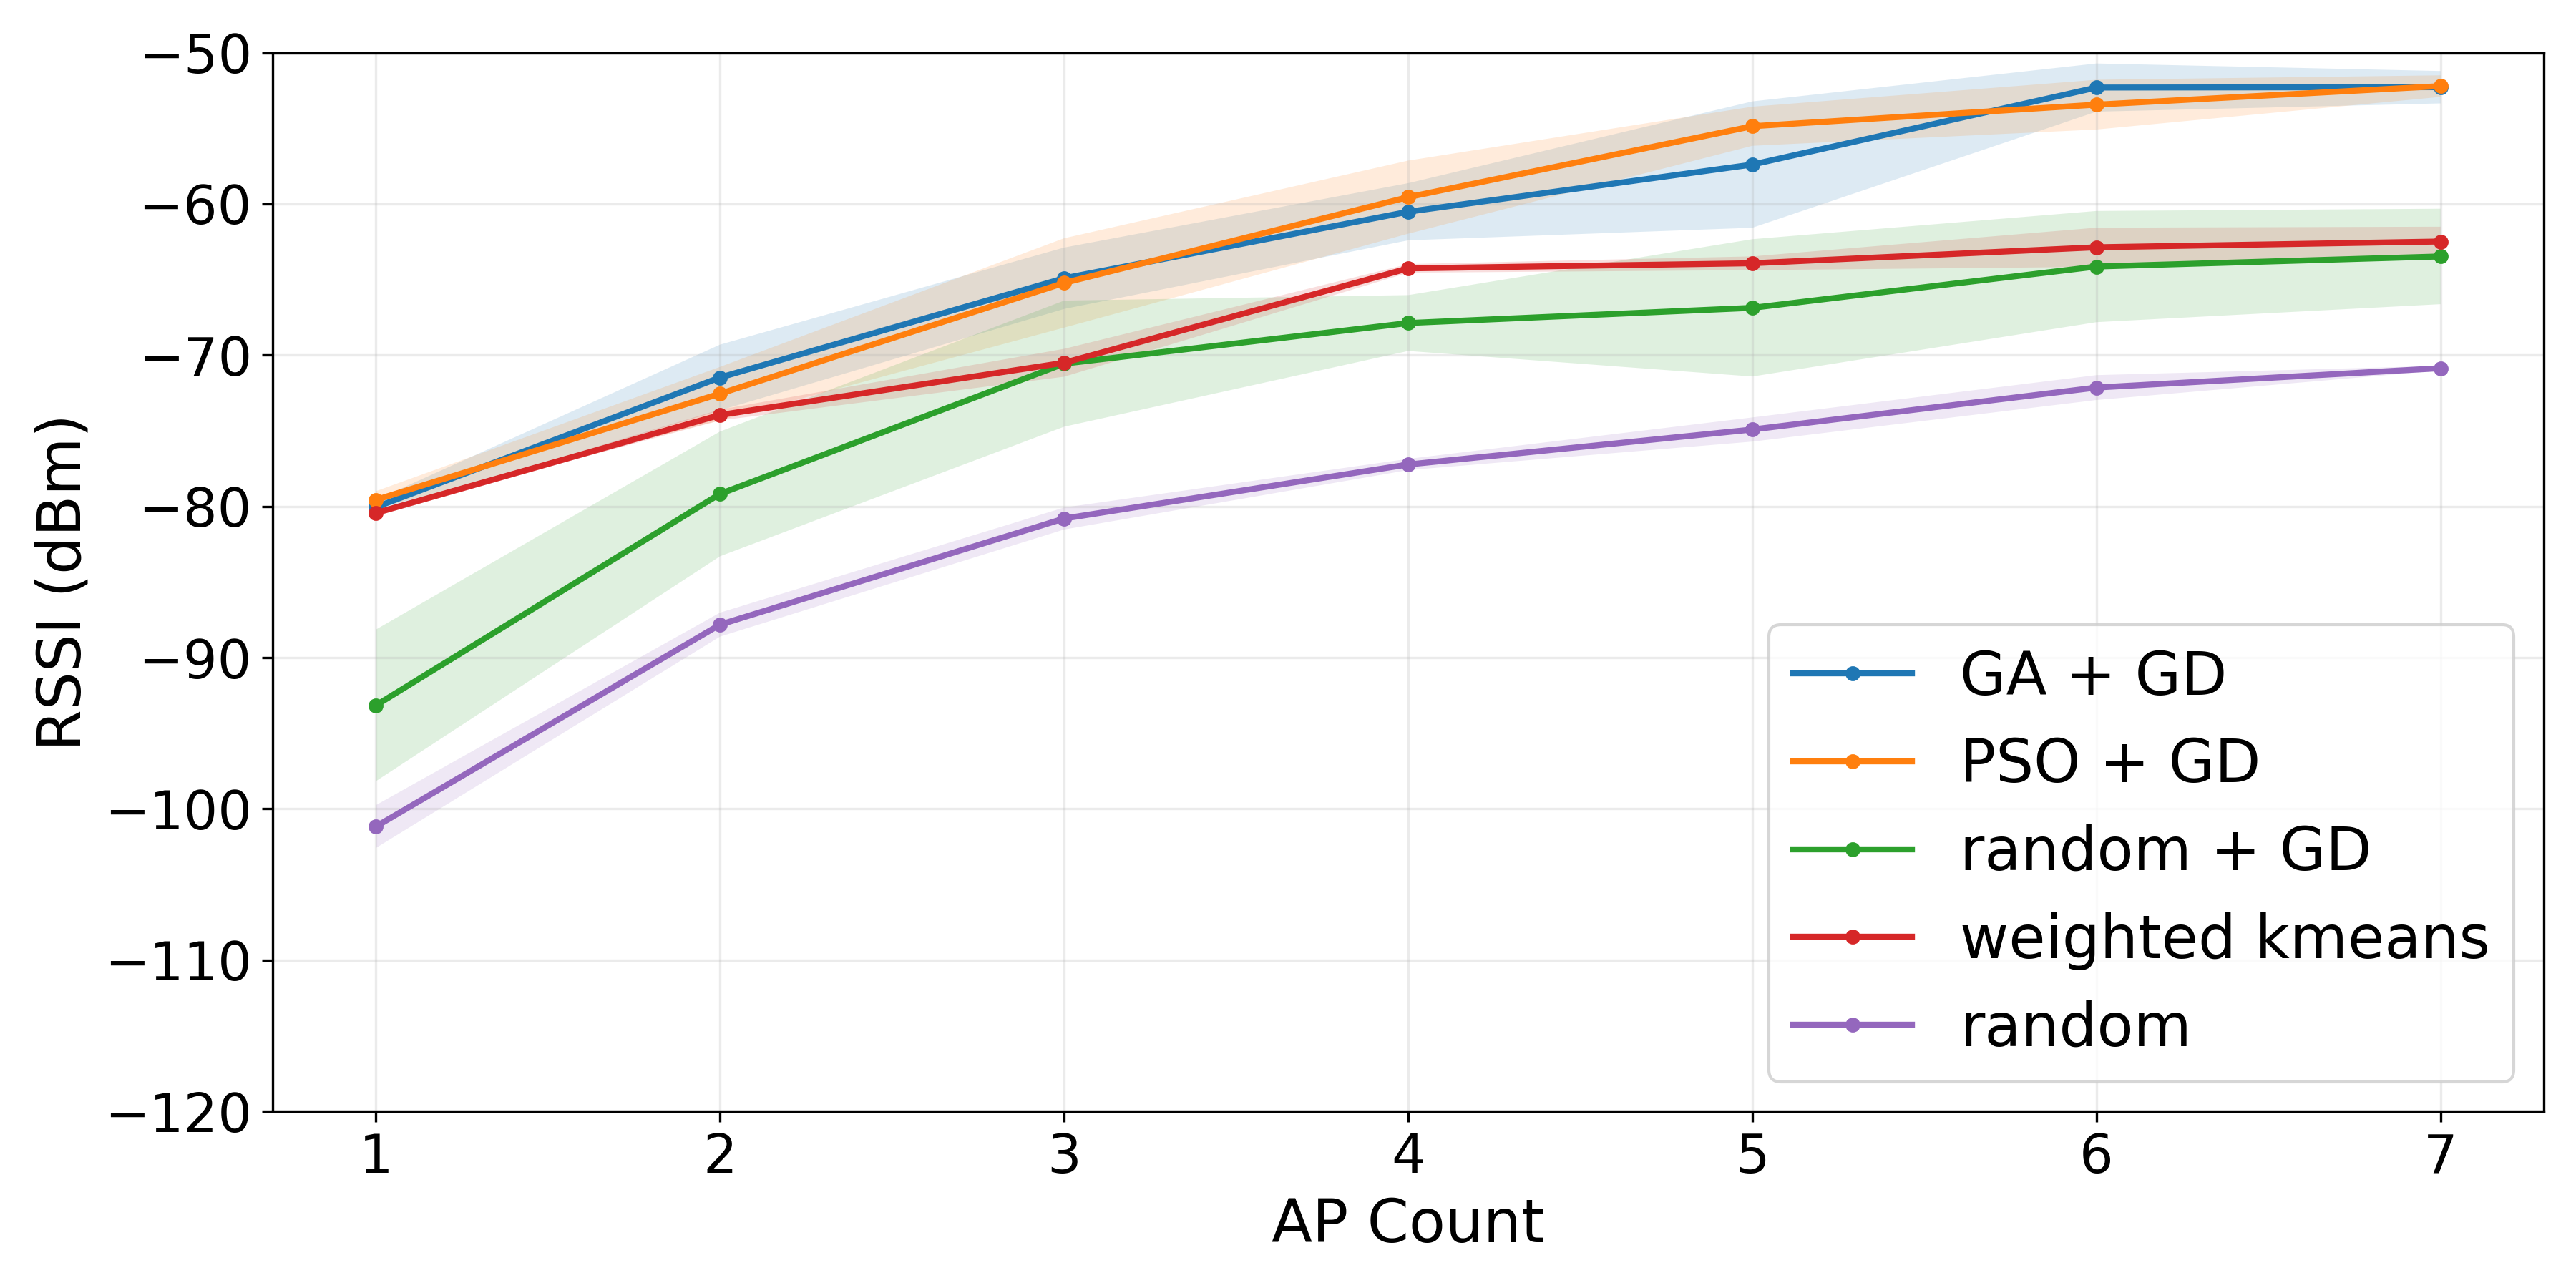

## Plot: elbow_priority_p5_rss_dbm.png

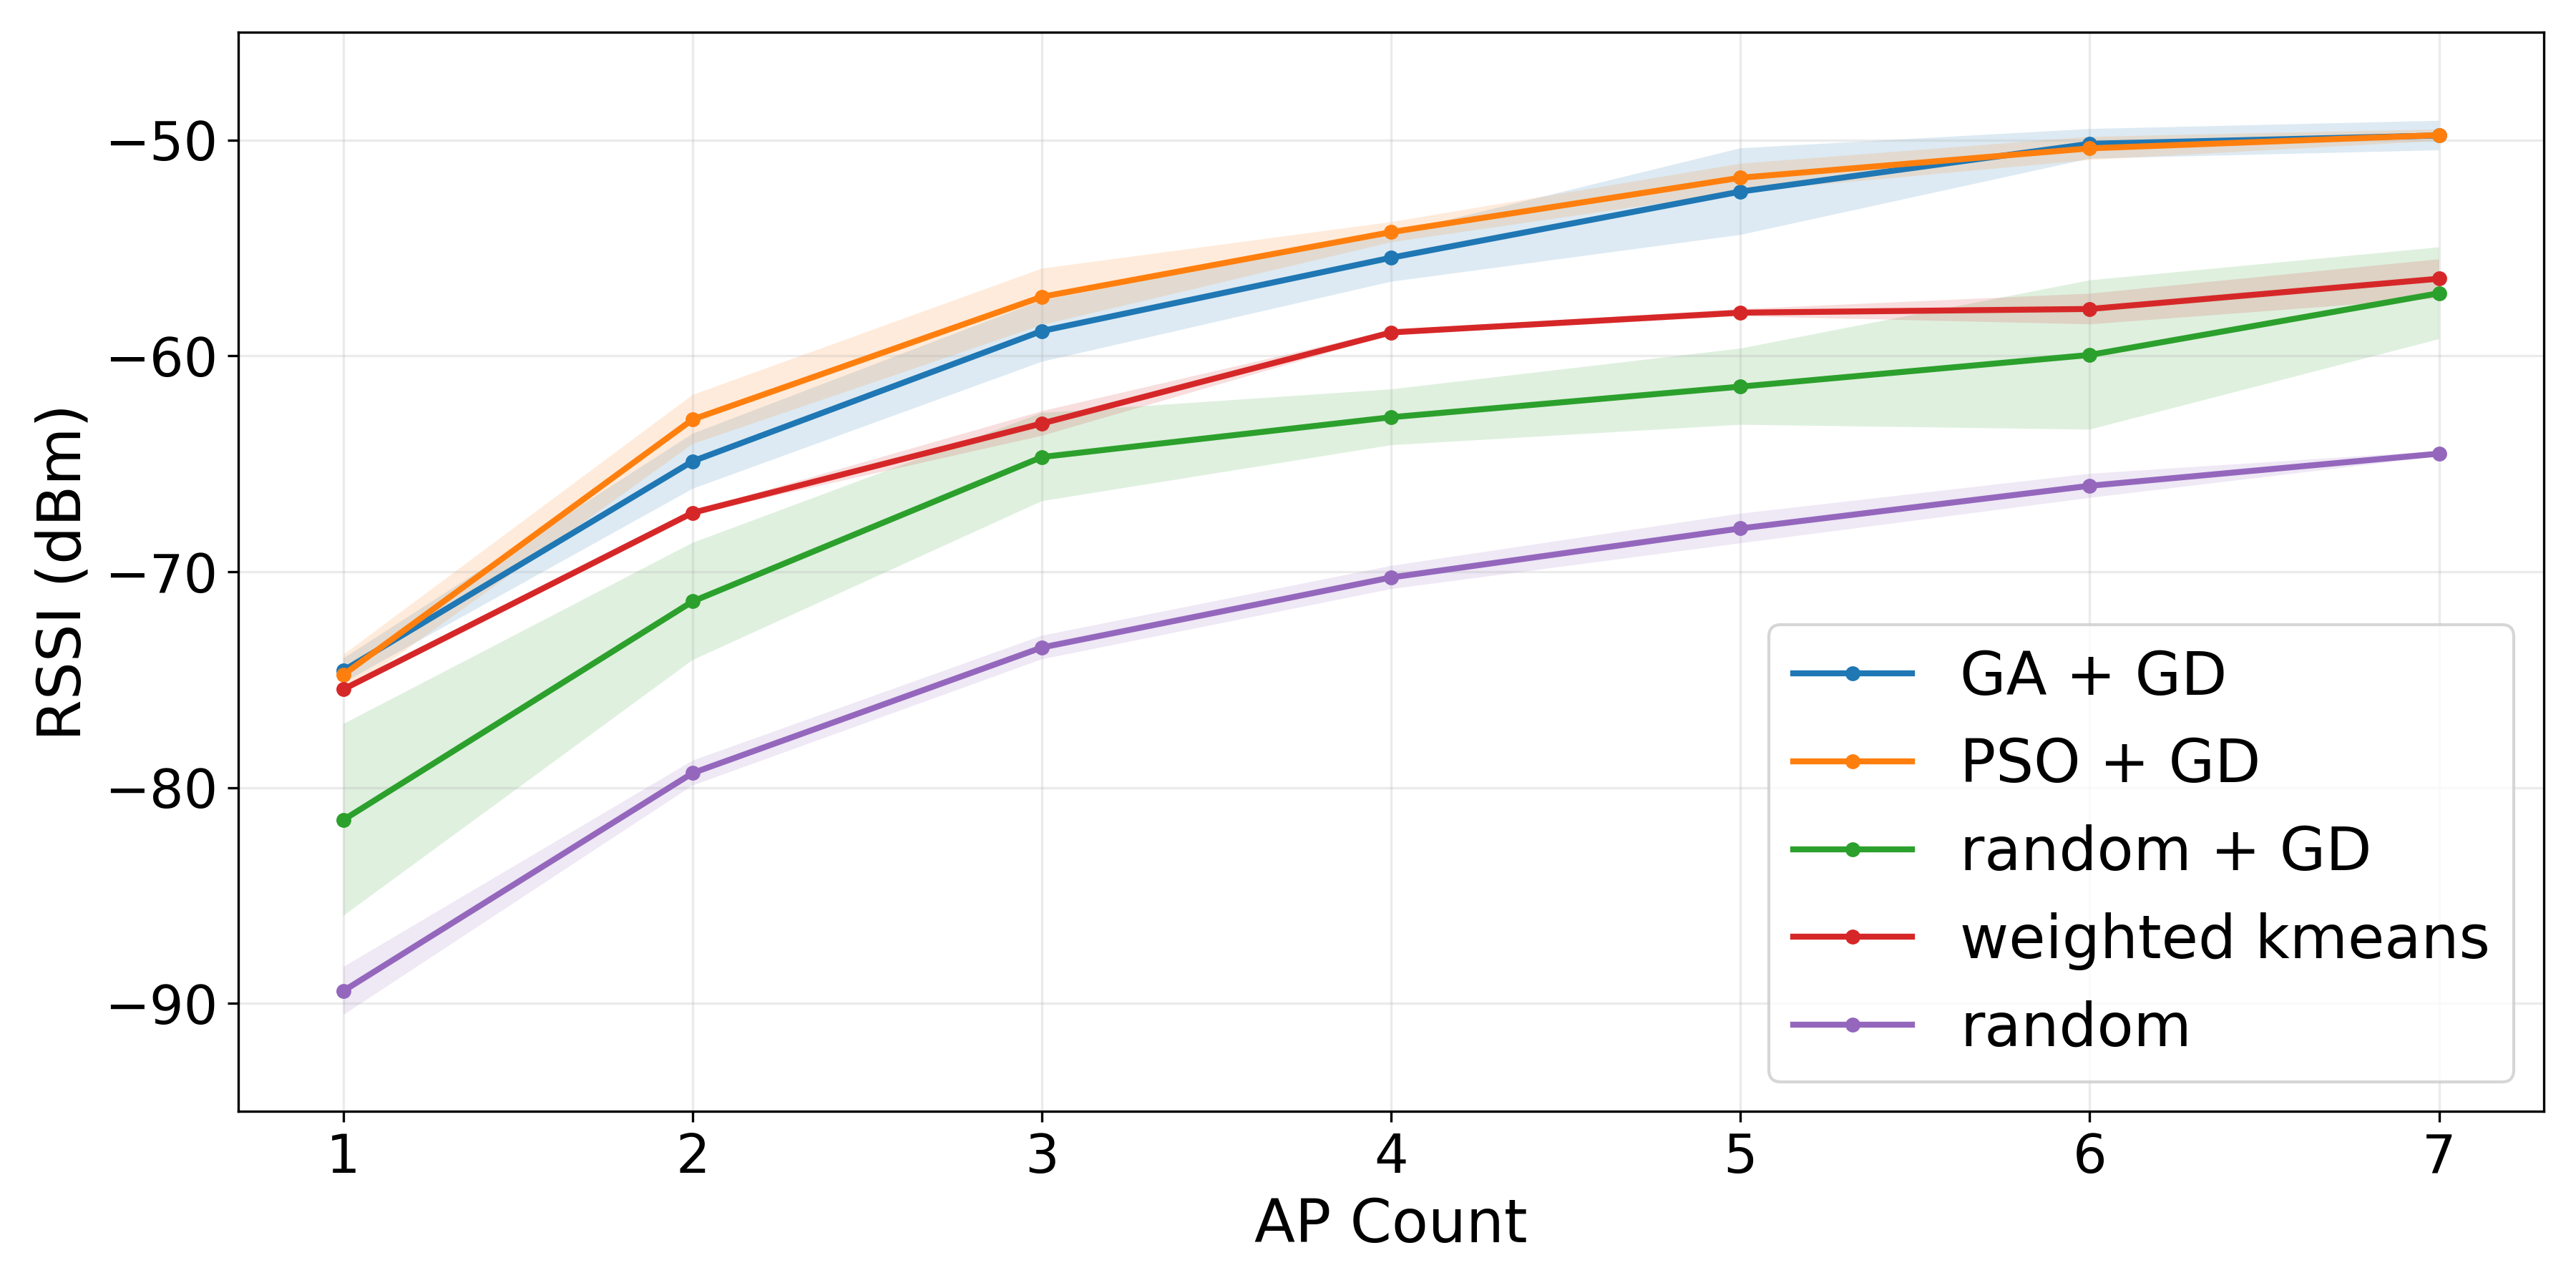

In [7]:
# Recreate all elbow figures, display them inline, and print tables per method
elbow_data = load_elbow_data(DATA_PATH)

metric_order = [
    "primary_loss",
    "mean_rss_dbm",
    "min_rss_dbm",
    "p5_rss_dbm",
    "priority_mean_rss_dbm",
    "priority_min_rss_dbm",
    "priority_p5_rss_dbm",
]

# Optional method ordering for visual consistency across all figures and tables
method_order = ["memetic", "pso_gd", "random_gd", "weighted_kmeans", "random"]

# Optional fixed y-axis ranges per metric for cross-scenario comparisons.
# Use None to fall back to metric_payload["y_limits"] if available.
metric_y_axis_ranges: dict[str, tuple[float, float] | None] = {
    "primary_loss": None,
    "mean_rss_dbm": (-75, -40),
    "min_rss_dbm": (-120, -50),
    "p5_rss_dbm": (-95, -45),
    "priority_mean_rss_dbm": (-75, -40),
    "priority_min_rss_dbm": (-120, -50),
    "priority_p5_rss_dbm": (-95, -45),
}
# Example fixed ranges:
# metric_y_axis_ranges["mean_rss_dbm"] = (-85.0, -50.0)
# metric_y_axis_ranges["priority_mean_rss_dbm"] = (-90.0, -55.0)

# Optional override for mean_rss_dbm -> kmeans -> mean.
# Keep as None to disable, or provide a full replacement list.
kmeans_mean_override = None
# Example:
# kmeans_mean_override = [-67.5, -66.9, -66.2, -65.8, -65.3]

saved_paths = []
for metric_key in metric_order:
    metric_payload = elbow_data.get(metric_key)
    if not isinstance(metric_payload, Mapping):
        print(f"Skipping missing or invalid metric: {metric_key}")
        continue

    y_axis_range = metric_y_axis_ranges.get(metric_key)
    saved_path = plot_elbow_metric(
        metric_key=metric_key,
        metric_payload=metric_payload,
        output_dir=OUTPUT_DIR,
        with_error_band=True,
        method_order=method_order,
        y_axis_range=y_axis_range,
    )
    saved_paths.append(saved_path)
    print(f"Saved: {saved_path}")
    if y_axis_range is not None:
        print(f"Applied y-axis range for {metric_key}: ({float(y_axis_range[0])}, {float(y_axis_range[1])})")

print(f"\nGenerated {len(saved_paths)} elbow plot(s) in {OUTPUT_DIR}")

display(Markdown("# Generated Elbow Plots"))
display_saved_plots(saved_paths)